In [2]:
## Plots for the onion air mattress paper

## Define colours for the different simulations (realistic, simplified_circular, simplified_oval)

colours = {
    'realistic': 'blue',
    'simplified_circular': 'orange',
    'simplified_oval': 'green'
}


17


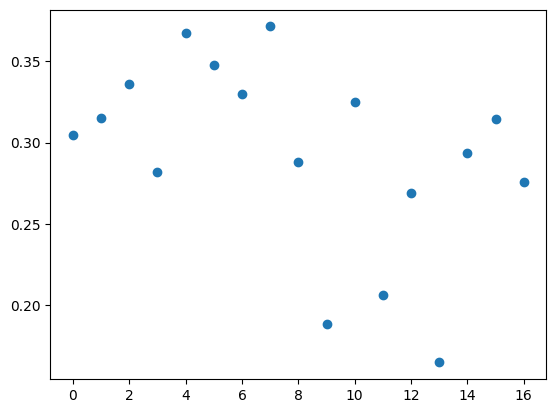

Selected meshes: ['1_2', '1_3', '1_4', '1_5', '1_6', '1_8', '2_1', '2_3', '2_6a', '2_7', '3_2', '3_4', '3_6', '3_7']


In [3]:
## Create a mask to filter out the confocal data for which the pore length is less than a predetermined proportion of the stomata length

import matplotlib.pyplot as plt

stomata_length = [43, 40,40.5, 48.2, 45.2, 40.3, 37, 39.6, 37.5, 36, 40, 42.1, 41.6, 40.6, 40.5, 45.5, 41]
pore_length = [13.1, 12.6, 13.6, 13.6, 16.6, 14.0, 12.2, 14.7, 10.8, 6.8, 13.0, 8.7, 11.2, 6.7, 11.9, 14.3, 11.3]
mesh_ids =["1_2","1_3","1_4","1_5","1_6","1_8","2_1", "2_3", "2_6a", "2_6b", "2_7","3_1","3_2", "3_3", "3_4","3_6", "3_7"]
print(len(mesh_ids))

pore_proportion = [p / s for p, s in zip(pore_length, stomata_length)]

plt.plot(pore_proportion, 'o')
plt.show()

## Based on this plot, let's take a threshold of 0.25

threshold = 0.25
prop_mask = [p > threshold for p in pore_proportion]
selected_meshes = [m for m, keep in zip(mesh_ids, prop_mask) if keep]
print("Selected meshes:", selected_meshes)

In [ ]:




# Build a lookup dictionary for fast updates
row_lookup = {(row["Mesh ID"], row["Pressure (MPa)"]): row for row in rows}

for file in mesh_files:
    mesh_id = "_".join(file.stem.split("_")[2:4])
    pressure = float(file.stem.split("_")[-1])
    pressure = round(pressure, 2)
    section_points_right, section_points_left, section_traces_left, section_traces_right = csh.analyze_stomata_mesh(
        file, num_sections=20, n_points=40, visualize=False
    )
    lr, major_length_l, minor_length_l = csh.calculate_cross_section_aspect_ratios_and_lengths(section_points_left[10])
    rr, major_length_r, minor_length_r = csh.calculate_cross_section_aspect_ratios_and_lengths(section_points_right[10])
    # Update the row directly using the lookup
    key = (mesh_id, pressure)
    if key in row_lookup:
        row_lookup[key]["Midsection AR left"] = lr
        row_lookup[key]["Midsection AR right"] = rr


df = pd.DataFrame(rows)
df.sort_values(by=["Mesh ID"], inplace=True)
display(df)



In [27]:
import numpy as np
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed

def process_mesh(file):
    mesh_id = "_".join(file.stem.split("_")[2:4])
    pressure = float(file.stem.split("_")[-1])
    pressure = round(pressure, 2)
    section_points_right, section_points_left, section_traces_left, section_traces_right = csh.analyze_stomata_mesh(
        file, num_sections=20, n_points=40, visualize=False
    )
    mid_index = len(section_points_left) // 2
    left_midsection = section_points_left[mid_index]
    right_midsection = section_points_right[mid_index]
    lr, major_length_l, minor_length_l = csh.calculate_cross_section_aspect_ratios_and_lengths(left_midsection)
    rr, major_length_r, minor_length_r = csh.calculate_cross_section_aspect_ratios_and_lengths(right_midsection)
    return {
        "Mesh ID": mesh_id,
        "Pressure (MPa)": pressure,
        "Midsection AR left": lr,
        "Midsection AR right": rr,
        "Midsection Points Left": left_midsection,
        "Midsection Points Right": right_midsection,
        "Major length left": major_length_l,
        "Major length right": major_length_r,
        "Minor length left": minor_length_l,
        "Minor length right": minor_length_r,
    }

# Parallel processing
results = []
with ThreadPoolExecutor() as executor:
    futures = [executor.submit(process_mesh, file) for file in mesh_files]
    for future in as_completed(futures):
        results.append(future.result())

df = pd.DataFrame(results)
df.sort_values(by=["Mesh ID"], inplace=True)
display(df)

,Mesh ID,Pressure (MPa),Midsection AR left,Midsection AR right,Midsection Points Left,Midsection Points Right,Major length left,Major length right,Minor length left,Minor length right
105,1_2,0.5,[1.0636601395102618],[1.126495288344788],"[[-7.116786310165259, -0.876510605789347, 5.16...","[[14.855680215265956, 1.5418653165934717, -6.4...",[14.194866544735673],[15.500838960880236],[13.345302712266136],[13.760234171646061]
149,1_2,0.2,[1.142160554217184],[1.1712930647475337],"[[-15.592959330608586, -0.3262197220258022, -4...","[[8.432637454587182, 0.08465305825779662, 5.63...",[14.47719720425118],[15.413550766648239],[12.675273323699738],[13.159431427155724]
335,1_2,1.9,[0.9946492086118335],[1.0581019483479754],"[[-2.232309003153248, 0.6420709012863005, -0.8...","[[20.97920745206184, -1.3509709147005722, -1.8...",[14.81305996718951],[16.28606067613321],[14.892747954691608],[15.391768913724043]
148,1_2,0.3,[1.1206498005939824],[1.1393528521290945],"[[-2.1222391315116163, -0.06864579540096732, -...","[[12.247094192631739, 1.4824844689091576, -6.4...",[14.419696950993567],[15.326700383187786],[12.86726410280057],[13.45211042790385]
38,1_2,1.3,[1.0052293794796594],[1.08149194505828],"[[-9.556449393941524, 1.9708555193429207, -7.5...","[[20.815357130334405, -1.41166354973275, -0.82...",[14.42156414831139],[15.935932496585613],[14.34654064306843],[14.73513748244038]
...,...,...,...,...,...,...,...,...,...,...
293,3_7,0.9,[1.0748576361365514],[1.0207960539329368],"[[-5.207038846663894, -13.986523295522849, 2.1...","[[5.550077013589767, 15.383304895623274, -0.29...",[14.670947032794292],[13.040762136161533],[13.64920017271057],[12.775090661761386]
114,3_7,1.2,[1.0578538648958582],[1.011686424909203],"[[-3.0489639976770366, -8.901285239977497, 5.5...","[[5.65759554796737, 15.346235681086121, 2.4235...",[14.77691605669839],[13.18284002564547],[13.968768794121788],[13.030559372019452]
101,3_7,1.3,[1.0563634222667948],[1.0110584479571374],"[[-0.299522600057875, -1.1771538573267184, -0....","[[5.695996318243066, 15.253568419154421, 2.810...",[14.839674419364002],[13.249229259238076],[14.047887409354182],[13.104315864239494]
180,3_7,1.8,[1.0387607981354472],[1.0024421100535745],"[[-1.5692633270650922, -3.24017173776696, -6.5...","[[4.382731999256032, 11.810431831390988, 6.959...",[15.08212929728737],[13.5112469320562],[14.519347788595276],[13.478331363527918]


In [28]:
df.to_csv("results_df.csv", index=False)
np.save('midsection_points_left.npy', df['Midsection Points Left'].to_numpy(), allow_pickle=True)
np.save('midsection_points_right.npy', df['Midsection Points Right'].to_numpy(), allow_pickle=True)

In [18]:
import pandas as pd

df= pd.read_csv("results_df.csv")

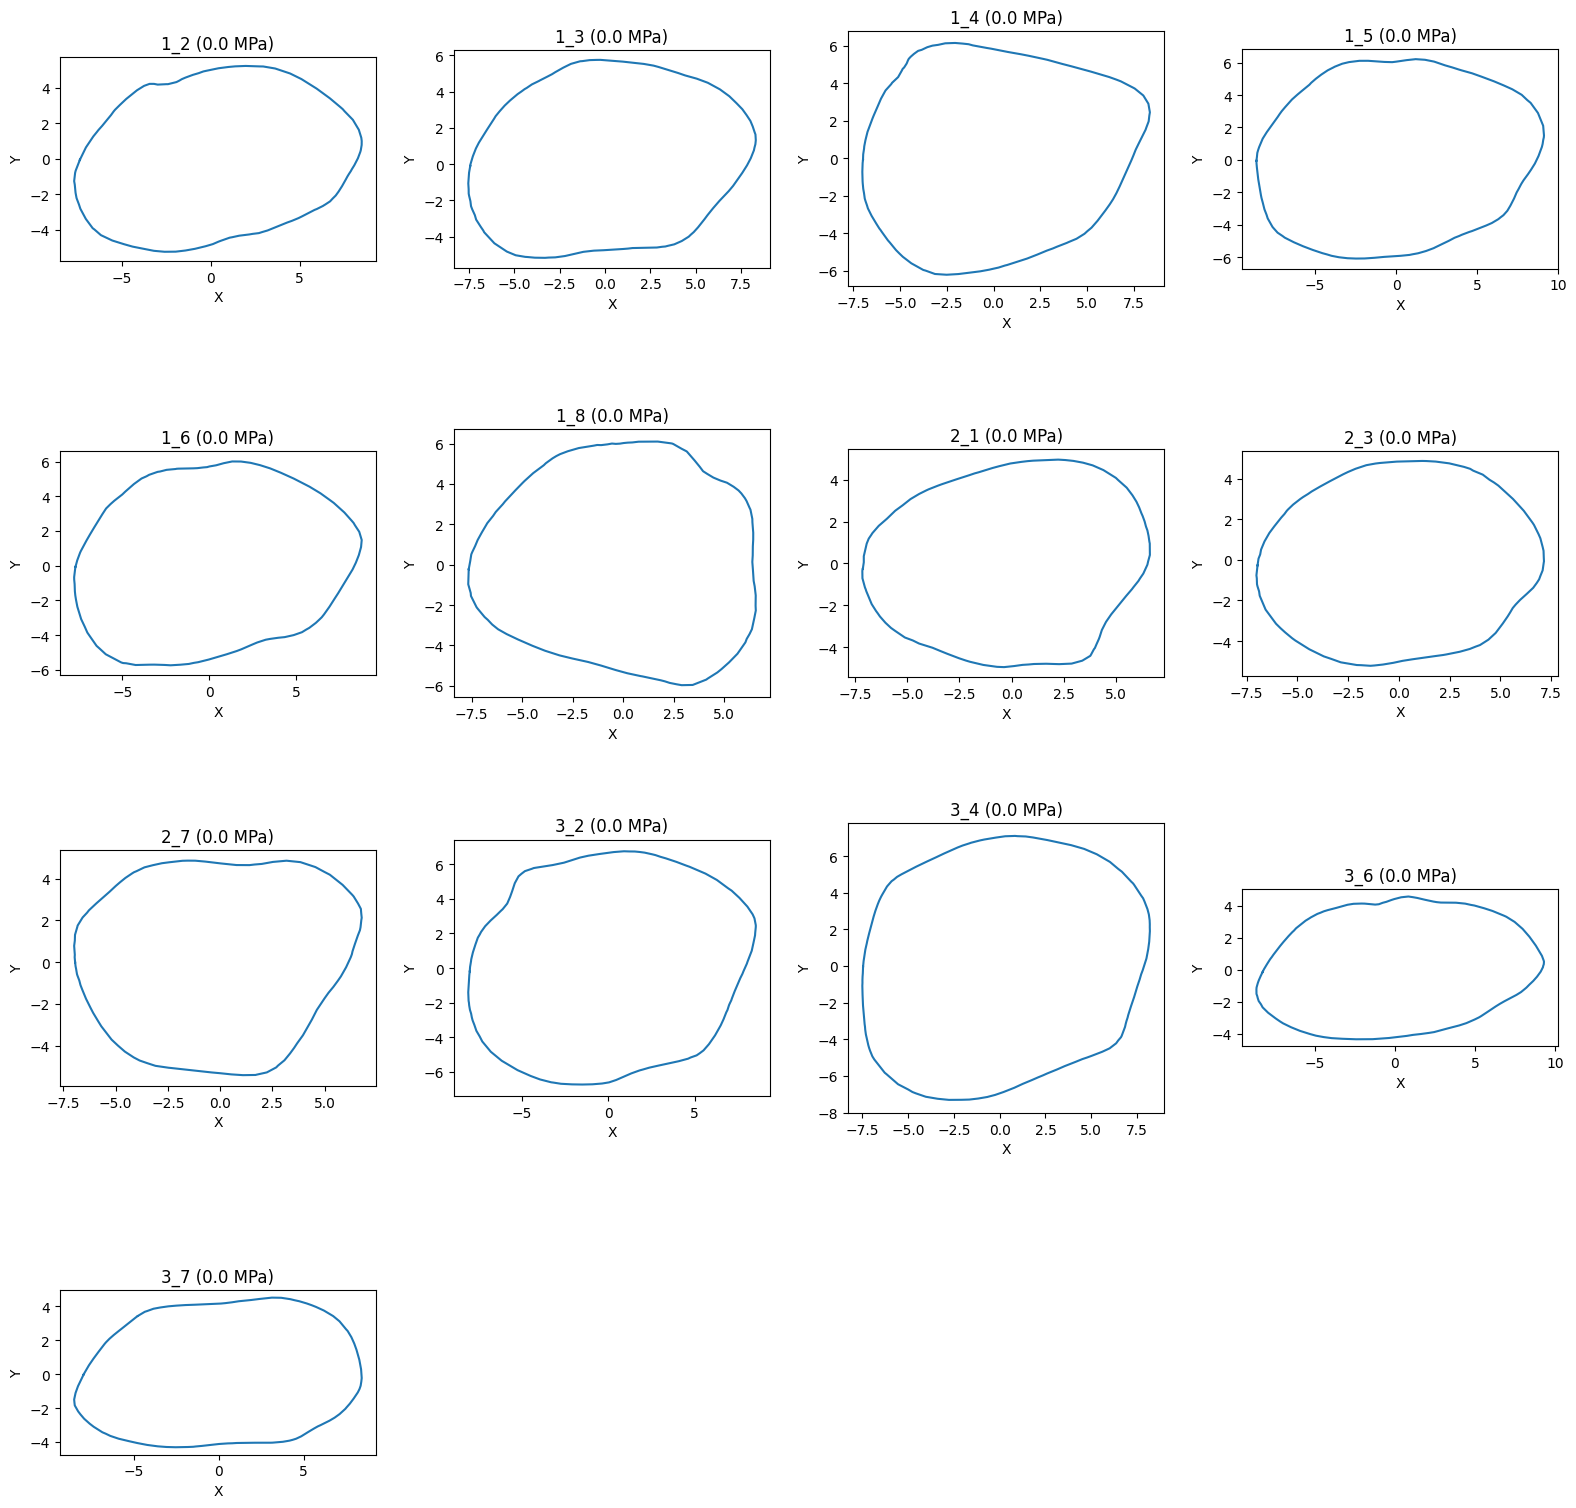

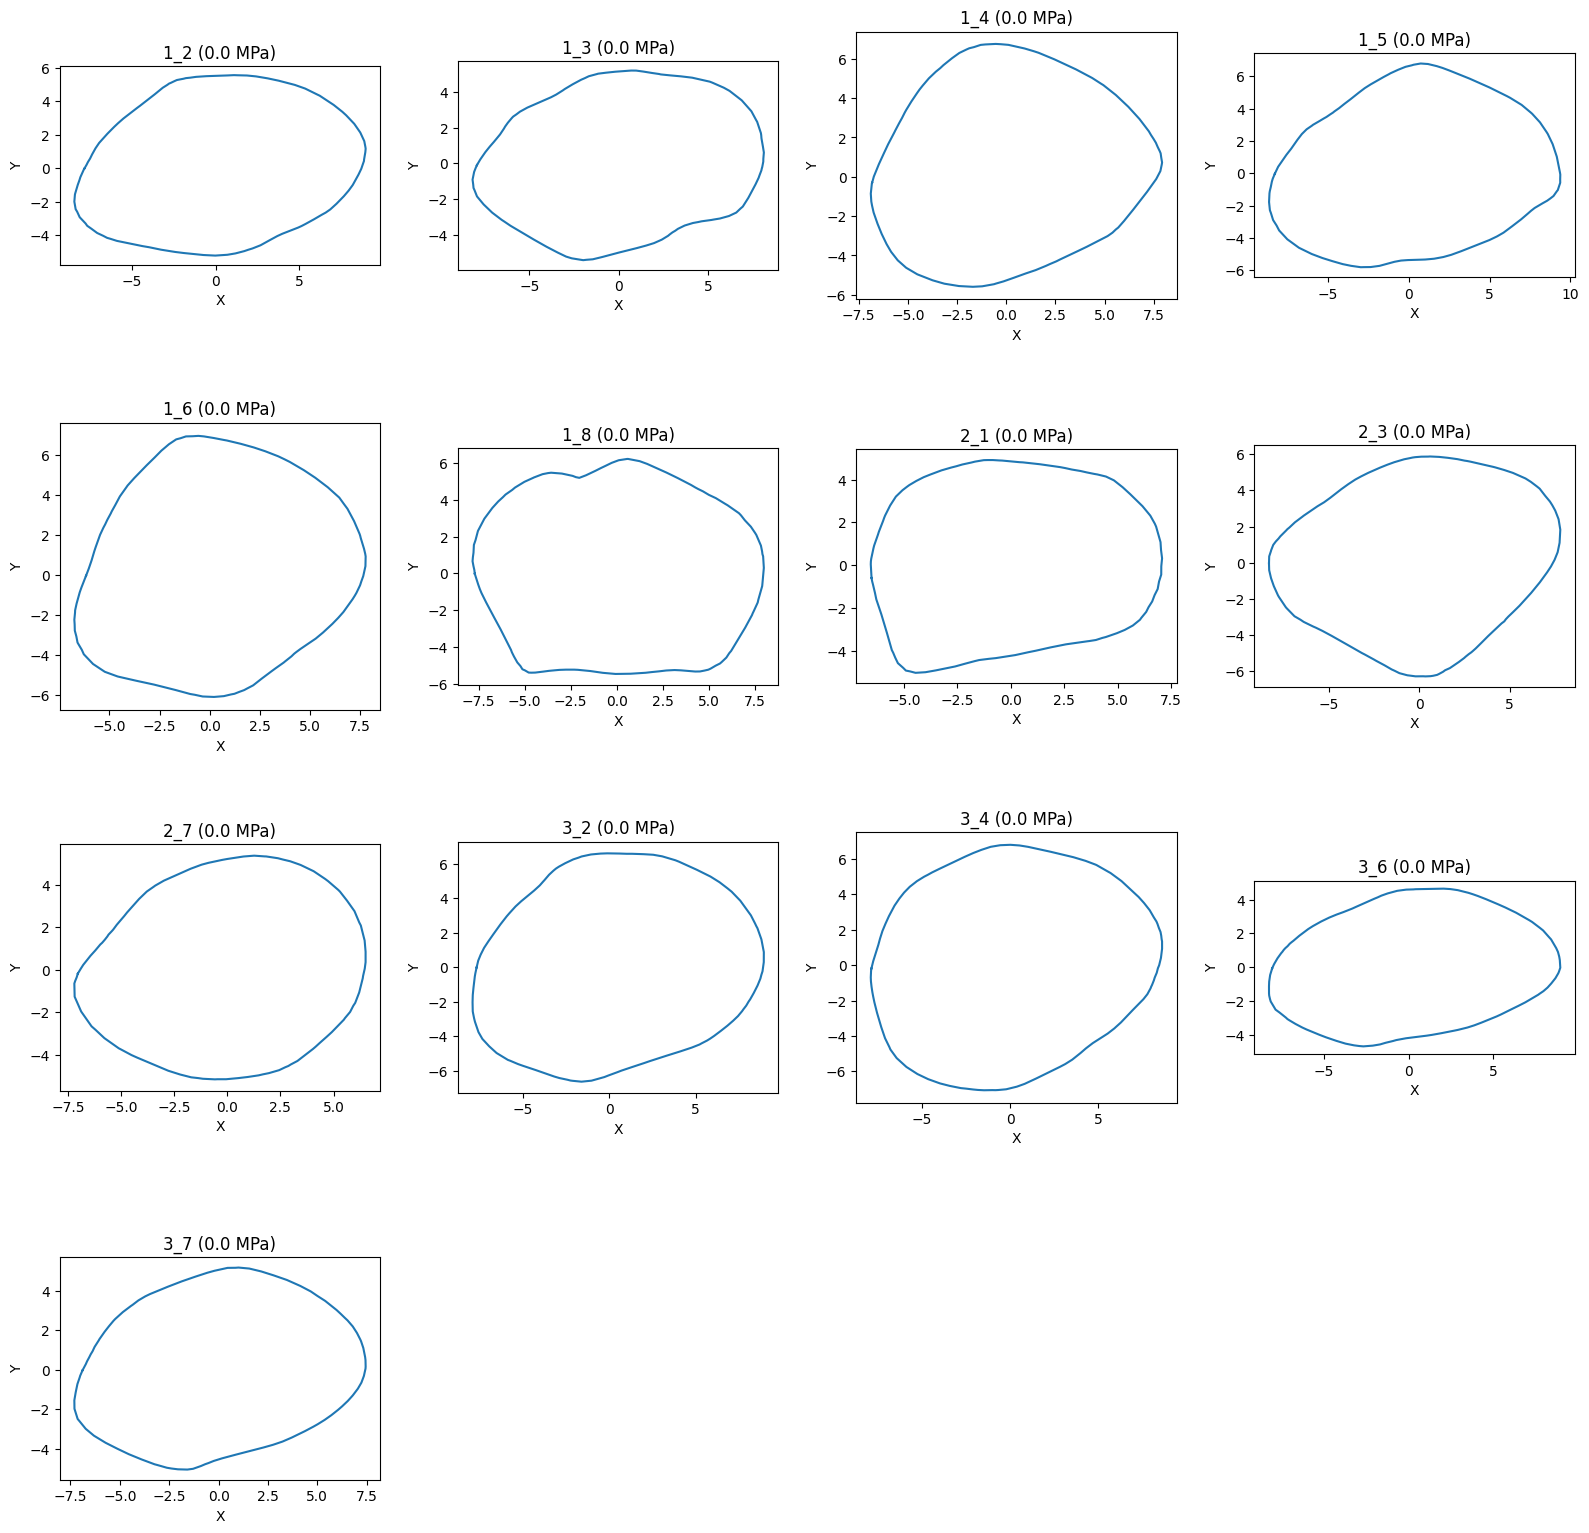

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import re

# Filter dataframe for selected meshes and pressure == 0.0
df_selected = df[(df["Mesh ID"].isin(selected_meshes)) & (df["Pressure (MPa)"] == 0.0)]
n = len(df_selected)
cols = int(np.ceil(np.sqrt(n)))
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows), squeeze=False)

for idx, (_, row) in enumerate(df_selected.iterrows()):
    r, c = divmod(idx, cols)
    ax = axes[r][c]
    section = row["Midsection Points Left"]
    if isinstance(section, str):
        section_clean = section.replace('[', '').replace(']', '').replace('\n', ' ')
        arr = np.fromstring(section_clean, sep=' ')
        section = arr.reshape(-1, 3)
    # If section is a list of cross-sections, pick the first one
    if isinstance(section, (list, np.ndarray)) and np.asarray(section).ndim > 2:
        section = section[0]
    pca = PCA(n_components=2)
    section_2d = pca.fit_transform(section)
    centroid = section_2d.mean(axis=0)
    rel = section_2d - centroid
    angles = np.arctan2(rel[:, 1], rel[:, 0])
    sort_idx = np.argsort(angles)
    section_2d_sorted = section_2d[sort_idx]
    section_2d_sorted = np.vstack([section_2d_sorted, section_2d_sorted[0]])
    ax.plot(section_2d_sorted[:, 0], section_2d_sorted[:, 1])
    ax.set_aspect('equal')
    ax.set_title(f'{row["Mesh ID"]} (0.0 MPa)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

# Hide unused subplots
for idx in range(n, rows*cols):
    r, c = divmod(idx, cols)
    fig.delaxes(axes[r][c])

plt.tight_layout()
plt.savefig('midsections_left.png', dpi=300)
plt.show()

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows), squeeze=False)

for idx, (_, row) in enumerate(df_selected.iterrows()):
    r, c = divmod(idx, cols)
    ax = axes[r][c]
    section = row["Midsection Points Right"]
    if isinstance(section, str):
        section_clean = section.replace('[', '').replace(']', '').replace('\n', ' ')
        arr = np.fromstring(section_clean, sep=' ')
        section = arr.reshape(-1, 3)
    # If section is a list of cross-sections, pick the first one
    if isinstance(section, (list, np.ndarray)) and np.asarray(section).ndim > 2:
        section = section[0]
    pca = PCA(n_components=2)
    section_2d = pca.fit_transform(section)
    centroid = section_2d.mean(axis=0)
    rel = section_2d - centroid
    angles = np.arctan2(rel[:, 1], rel[:, 0])
    sort_idx = np.argsort(angles)
    section_2d_sorted = section_2d[sort_idx]
    section_2d_sorted = np.vstack([section_2d_sorted, section_2d_sorted[0]])
    ax.plot(section_2d_sorted[:, 0], section_2d_sorted[:, 1])
    ax.set_aspect('equal')
    ax.set_title(f'{row["Mesh ID"]} (0.0 MPa)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

# Hide unused subplots
for idx in range(n, rows*cols):
    r, c = divmod(idx, cols)
    fig.delaxes(axes[r][c])

plt.tight_layout()
plt.savefig('midsections_right.png', dpi=300)
plt.show()

In [20]:
## Load in and add the pore area to the dataframe

## All data has now been calculated automatically - the pore area for each pressure, and the resulting meshes for each pressure
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys

# Add parent directory to sys.path
parent_dir = str(Path.cwd().parent)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
import cross_section_helpers as csh

path_to_data = "../Meshes/"
confocal_results = "Onion meshes/pressure_pore/"
confocal_meshes = "Onion meshes/pressure_results/"

## Get all files in the folder
results_files = [f for f in Path(path_to_data + confocal_results).glob("*.txt")]
mesh_files = [f for f in Path(path_to_data + confocal_meshes).glob("*.obj")]

## Create the pressure values
pressures = np.arange(0,2.0,0.1)

# Build the initial rows list
rows = []
for file in results_files:
    mesh_id = "_".join(file.stem.split("_")[4:6])
    data = np.loadtxt(file)
    for pore_area, pressure in zip(data, pressures):
        pressure = round(pressure, 2)
        mask = (df["Mesh ID"] == mesh_id) & (df["Pressure (MPa)"] == pressure)
        df.loc[mask, "Pore Area (um²)"] = pore_area


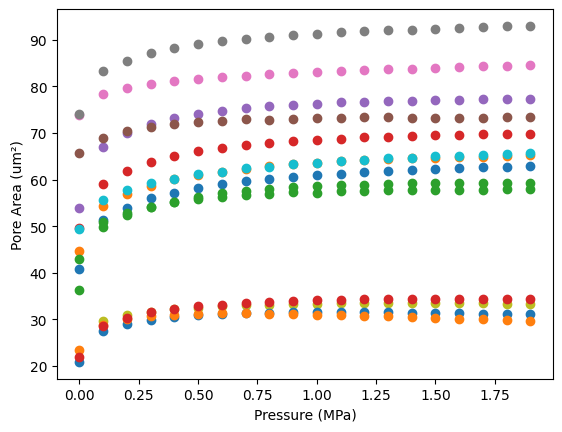

In [22]:
## Plot all of the pressure vs pore area curves
import matplotlib.pyplot as plt

for mesh_id in selected_meshes:
    mesh_data = df[df["Mesh ID"] == mesh_id]
    plt.plot(mesh_data["Pressure (MPa)"], mesh_data["Pore Area (um²)"], 'o', label=mesh_id)

plt.xlabel("Pressure (MPa)")
plt.ylabel("Pore Area (um²)")
plt.savefig("pressure_vs_pore_area_all_meshes.png", dpi=300)
plt.show()



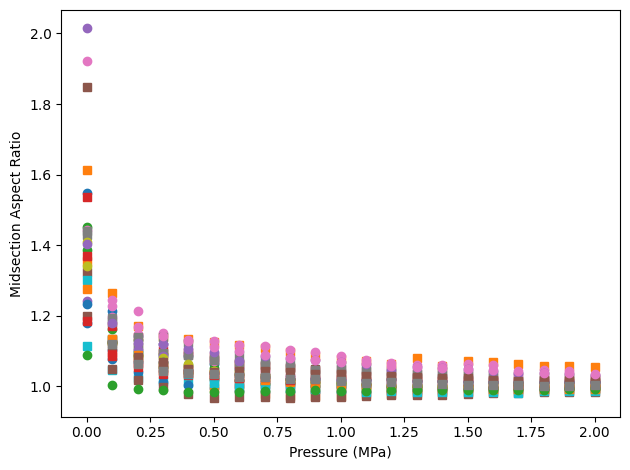

In [32]:
## Plot change in aspect ratio with pressure for the selected meshes
# Ensure all values are floats, not lists
df["Midsection AR left"] = df["Midsection AR left"].apply(lambda x: x[0] if isinstance(x, (list, np.ndarray)) else x)
df["Midsection AR right"] = df["Midsection AR right"].apply(lambda x: x[0] if isinstance(x, (list, np.ndarray)) else x)
for mesh_id in selected_meshes:
    mesh_data = df[df["Mesh ID"] == mesh_id]
    plt.plot(mesh_data["Pressure (MPa)"], mesh_data["Midsection AR left"], 'o', label=f"{mesh_id} left")
    plt.plot(mesh_data["Pressure (MPa)"], mesh_data["Midsection AR right"], 's', label=f"{mesh_id} right")    
plt.xlabel("Pressure (MPa)")
plt.ylabel("Midsection Aspect Ratio")
plt.tight_layout()
plt.savefig("pressure_vs_aspect_ratio_all_meshes.png", dpi=300)
plt.show()

In [ ]:
## Select 3 values to plot (with different starting pore areas).
## This figure should comprise the 3 curves, plus the 3 starting mesh geometries.

sampled_meshes = ["1_2", "2_3", "3_1"]
mesh_colours = ['#377eb8', '#74add1', '#313695']  # medium, light, deep blue

for mesh_id, colour in zip(sampled_meshes, mesh_colours):
    mesh_data = df[df["Mesh ID"] == mesh_id]
    plt.plot(mesh_data["Pressure (MPa)"], mesh_data["Pore Area (um²)"], 'o', label=mesh_id, color=colour)
plt.xlabel("Pressure (MPa)")
plt.ylabel("Pore Area (um²)")

plt.legend()
plt.savefig("pressure_vs_pore_area_sampled_confocal.png", dpi=300)
plt.show()

## Plot the change in pore area for all meshes, highlighting the three selected meshes
## Let's just plot the confocal data

line_of_0_x = np.arange(0,80)
line_of_0_y = np.ones(len(line_of_0_x))

start_areas = df[df["Pressure (MPa)"] == 0.0]
end_areas = df[df["Pressure (MPa)"] == 1.9]

df_area_change = pd.DataFrame({
    "Mesh ID": start_areas["Mesh ID"].values,
    "Start Pore Area (um²)": start_areas["Pore Area (um²)"].values,
    "End Pore Area (um²)": end_areas["Pore Area (um²)"].values
})

df_area_change["Area change"] = df_area_change["End Pore Area (um²)"] / df_area_change["Start Pore Area (um²)"]


## Plot the values
plt.plot(df_area_change["Start Pore Area (um²)"], df_area_change["Area change"], 'o', label="All meshes", color=colours['realistic'])


for mesh_id, colour in zip(sampled_meshes, mesh_colours):
    mesh_data = df_area_change[df_area_change["Mesh ID"] == mesh_id]
    # Plot the original point (small filled marker)
    plt.scatter(mesh_data["Start Pore Area (um²)"], mesh_data["Area change"],
                s=40, color=colour, label=mesh_id, zorder=3)
    # Overlay a larger hollow circle of the same color
    plt.scatter(mesh_data["Start Pore Area (um²)"], mesh_data["Area change"],
                s=200, facecolors='none', edgecolors=colour, linewidths=2, zorder=4)
plt.plot(line_of_0_y, 'r-')
plt.legend()
plt.xlabel("Starting Pore Area (um²)")
plt.ylabel("End Pore Area / Start Pore Area")
plt.savefig("area_change_sampled_confocal.png", dpi=300)
plt.show()

In [ ]:
## Helper functions for the mesh view plots

import trimesh

def orient_top_view(tri: trimesh.Trimesh) -> trimesh.Trimesh:
    V = tri.vertices - tri.vertices.mean(axis=0)
    # SVD on covariance
    U, S, VT = np.linalg.svd(np.cov(V.T))
    axes = VT  # principal axes
    # Align smallest-variance axis to Z (torus plane normal)
    z_target = np.array([0.0, 0.0, 1.0])
    z_src = axes[-1]
    v = np.cross(z_src, z_target)
    c = float(np.dot(z_src, z_target))
    if np.linalg.norm(v) < 1e-8:
        R = np.eye(3) if c > 0 else np.diag([1, -1, -1])
    else:
        vx = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])
        R = np.eye(3) + vx + vx @ vx * (1.0 / (1.0 + c))
    tri_oriented = tri.copy()
    tri_oriented.apply_translation(-tri_oriented.vertices.mean(axis=0))
    tri_oriented.apply_transform(np.block([[R, np.zeros((3,1))],[np.zeros((1,3)), 1]]))
    return tri_oriented

# Helper: align in-plane so the major XY axis points along +Y (vertical)
def align_inplane_to_Y(tri: trimesh.Trimesh) -> trimesh.Trimesh:
    verts = tri.vertices.copy()
    xy = verts[:, :2] - verts[:, :2].mean(axis=0)
    C = np.cov(xy.T)
    w, v = np.linalg.eig(C)  # columns of v are eigenvectors
    idx = int(np.argmax(w))
    major = v[:, idx]
    # Rotation around Z by delta so that major -> +Y
    alpha = float(np.arctan2(major[1], major[0]))  # current angle of major vs +X
    delta = np.pi/2 - alpha  # rotate so it points to +Y
    ca, sa = np.cos(delta), np.sin(delta)
    Rz = np.array([[ca, -sa, 0], [sa, ca, 0], [0, 0, 1]])
    tri_rot = tri.copy()
    tri_rot.apply_transform(np.block([[Rz, np.zeros((3,1))],[np.zeros((1,3)), 1]]))
    # Optional: ensure a consistent left/right (minor axis pointing +X)
    minor = v[:, 1-idx]  # the other eigenvector
    minor_rot = Rz[:2, :2] @ minor
    if minor_rot[0] < 0:  # flip 180° if pointing to -X
        Rz_flip = np.array([[-1, 0, 0], [0, -1, 0], [0, 0, 1]])
        tri_rot.apply_transform(np.block([[Rz_flip, np.zeros((3,1))],[np.zeros((1,3)), 1]]))
    return tri_rot

from pathlib import Path

def find_dir(rel_path: Path, start: Path = None) -> Path:
    """
    Search upwards from 'start' (or current working directory) for a directory matching rel_path.
    Returns the first match found, or raises FileNotFoundError.
    """
    if start is None:
        start = Path.cwd()
    for parent in [start] + list(start.parents):
        candidate = parent / rel_path
        if candidate.exists() and candidate.is_dir():
            return candidate
    raise FileNotFoundError(f"Could not find directory '{rel_path}' relative to {start}")

def rotate_y_90(mesh: trimesh.Trimesh, sign: int = 1) -> trimesh.Trimesh:
    # sign = +1 => +90°, sign = -1 => -90° about Y
    ang = sign * (np.pi / 2)
    ca, sa = np.cos(ang), np.sin(ang)
    Ry = np.array([[ca, 0, sa],[0, 1, 0],[-sa, 0, ca]])
    tri = mesh.copy()
    tri.apply_transform(np.block([[Ry, np.zeros((3,1))],[np.zeros((1,3)), 1]]))
    return tri


def rotate_z_90(mesh: trimesh.Trimesh, sign: int = 1) -> trimesh.Trimesh:
    # sign = +1 => +90°, sign = -1 => -90° about Z
    ang = sign * (np.pi / 2)
    ca, sa = np.cos(ang), np.sin(ang)
    Rz = np.array([[ca, -sa, 0],[sa, ca, 0],[0, 0, 1]])
    tri = mesh.copy()
    tri.apply_transform(np.block([[Rz, np.zeros((3,1))],[np.zeros((1,3)), 1]]))
    return tri

In [ ]:
## Display the three starting geometries
# Requirements: trimesh, numpy, matplotlib

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Conversion: how many micrometers (µm) per mesh unit
MICRONS_PER_UNIT = 1.0  

# Desired common scale bar length (µm) and label size
SB_LEN_UM = 10.0  # show 10 µm
LABEL_SIZE = 14   # larger font

# Get the paths for all of the meshes: realistic, idealised_circular, idealised_oval
# Set the directories
ORIG_REL = Path('Meshes') / 'Onion_OBJ'
IDEAL_REL = Path('Meshes') / 'Idealised'

root = Path.cwd()
orig_dir = find_dir(ORIG_REL, root)
ideal_dir = find_dir(IDEAL_REL, root)

# Collect original meshes (.obj) matching sampled_meshes
orig_paths = sorted([p for p in orig_dir.glob('*.obj') if any(sel in p.stem for sel in sampled_meshes)])

# Collect idealised meshes (.ply preferred, fallback to .obj), matching sampled_meshes
ideal_paths = []
for sel in sampled_meshes:
    ply = next(ideal_dir.glob(f'*{sel}*.ply'), None)
    if ply is not None:
        ideal_paths.append(ply)
    else:
        obj = next(ideal_dir.glob(f'*{sel}*.obj'), None)
        if obj is not None:
            ideal_paths.append(obj)

# Separate idealised meshes into oval and circular, matching sampled_meshes
idealised_circular_paths = []
idealised_oval_paths = []

for sel in sampled_meshes:
    # Circular: must contain 'equal'
    circ = next(ideal_dir.glob(f'*{sel}*equal*.ply'), None)
    if circ is not None:
        idealised_circular_paths.append(circ)
    # Oval: must NOT contain 'equal' or 'bulged'
    oval = next((p for p in ideal_dir.glob(f'*{sel}*.ply') if 'equal' not in p.name and 'bulged' not in p.name), None)
    if oval is not None:
        idealised_oval_paths.append(oval)

labels = [p.stem for p in orig_paths]

print("Original meshes:", [p.name for p in orig_paths])
print("Idealised meshes:", [p.name for p in idealised_circular_paths])
print("Idealised oval meshes:", [p.name for p in idealised_oval_paths])

In [ ]:
## Original meshes: orig_paths
## Idealised meshes: idealised_circular_paths
## Idealised oval meshes: idealised_oval_paths

# Use the first three original meshes for display
## Set the colours for the original meshes

mesh_colours = ['#377eb8', '#74add1', '#313695']  # medium, light, deep blue

# Load and orient meshes
tri_meshes = []
for mp in orig_paths[:3]:
    tri = trimesh.load(mp, force='mesh')
    if not isinstance(tri, trimesh.Trimesh):
        tri = tri.dump().sum()  # convert scene to a single mesh if needed
    tri = orient_top_view(tri)
    tri = align_inplane_to_Y(tri)
    tri_meshes.append(tri)

# Compute global extent and spacing
all_vertices = np.vstack([m.vertices for m in tri_meshes])
glob_min = all_vertices.min(axis=0)
glob_max = all_vertices.max(axis=0)
scene_size = glob_max - glob_min

# Offsets along X to avoid overlap in a single scene
widths_x = []
centers_x = []
for m in tri_meshes:
    vmin = m.vertices.min(axis=0)
    vmax = m.vertices.max(axis=0)
    widths_x.append(float(vmax[0] - vmin[0]))
    centers_x.append(float((vmin[0] + vmax[0]) * 0.5))
spacing = 1.3 * max(widths_x)
offsets_x = np.array([-spacing, 0.0, spacing])

# Prepare shifted copies for rendering
shifted_meshes = []
for m, dx in zip(tri_meshes, offsets_x):
    mc = m.copy()
    mc.apply_translation([dx, 0, 0])
    shifted_meshes.append(mc)

# Single common scale bar of fixed 10 µm
sb_len_um = SB_LEN_UM
sb_len_world = sb_len_um / MICRONS_PER_UNIT

# Scene bounds with shifted meshes
scene_min = np.vstack([m.vertices for m in shifted_meshes]).min(axis=0)
scene_max = np.vstack([m.vertices for m in shifted_meshes]).max(axis=0)

# Place the scale bar centered at x=0, below the lowest Y and just above top Z
center_x = 0.0
scene_extent = scene_max - scene_min
sb_y = scene_min[1] - 0.12 * scene_extent[1]
sb_z = scene_max[2] + 0.02 * (scene_extent[2] + 1e-6)

# Label positions (above each mesh)
label_positions = []
for m, dx, name in zip(tri_meshes, offsets_x, labels):
    vmin = m.vertices.min(axis=0) + np.array([dx, 0, 0])
    vmax = m.vertices.max(axis=0) + np.array([dx, 0, 0])
    x_c = 0.5 * (vmin[0] + vmax[0])
    y_top = vmax[1] + 0.06 * scene_extent[1]
    z_lbl = sb_z
    label_positions.append((x_c, y_top, z_lbl, name))

fig = plt.figure(figsize=(8,8), constrained_layout=True)
ax = fig.add_subplot(1,1,1, projection='3d')

# Draw meshes
all_min = np.array([np.inf, np.inf, np.inf])
all_max = -all_min

for i, tm in enumerate(shifted_meshes):
    faces = tm.faces
    verts = tm.vertices
    poly = Poly3DCollection(verts[faces], alpha=1.0)
    poly.set_facecolor(mesh_colours[i])
    poly.set_edgecolor('#1f3b75')
    poly.set_linewidth(0.2)
    ax.add_collection3d(poly)
    vmin = verts.min(axis=0)
    vmax = verts.max(axis=0)
    all_min = np.minimum(all_min, vmin)
    all_max = np.maximum(all_max, vmax)

# Include scale bar and labels in bounds
all_min = np.minimum(all_min, np.array([center_x - 0.5*sb_len_world, sb_y, sb_z]))
all_max = np.maximum(all_max, np.array([center_x + 0.5*sb_len_world, sb_y, sb_z]))
for x_c, y_top, z_lbl, _ in label_positions:
    all_min = np.minimum(all_min, np.array([x_c, y_top, z_lbl]))
    all_max = np.maximum(all_max, np.array([x_c, y_top, z_lbl]))

center = (all_min + all_max) / 2.0
extents = (all_max - all_min)
r = float(max(extents) / 2.0)

ax.set_xlim(center[0]-r, center[0]+r)
ax.set_ylim(center[1]-r, center[1]+r)
ax.set_zlim(center[2]-r, center[2]+r)

# Enforce equal aspect across axes to avoid distortion
try:
    ax.set_box_aspect((1,1,1))
except Exception:
    pass

# Top view, no axes
ax.view_init(elev=90, azim=-90)
ax.set_axis_off()

# Scale bar and label
ax.plot([center_x - 0.5*sb_len_world, center_x + 0.5*sb_len_world], [sb_y, sb_y], [sb_z, sb_z], c='k', lw=5, zorder=10)
ax.text(center_x, sb_y - 0.03*r, sb_z, f"{sb_len_um:g} µm", ha='center', va='top', color='k', fontsize=LABEL_SIZE)

# Mesh labels
for x_c, y_top, z_lbl, name in label_positions:
    ax.text(x_c, y_top, z_lbl, name, ha='center', va='bottom', color='k', fontsize=LABEL_SIZE)

plt.savefig("selected_meshes.png", dpi=300)
plt.show()

In [ ]:
## Let's create the idealised meshes. Get all of the measurements from the actual meshes
## 5 mins to run

import importlib
importlib.reload(csh)
import cross_section_helpers as csh

import sys
from pathlib import Path
import trimesh

# Add parent directory to sys.path
parent_dir = str(Path.cwd().parent)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

section_right = []
section_left = []

import cross_section_helpers as csh

for sm in selected_meshes:
    print(sm)
    mesh_path = "../Meshes/Onion_OBJ/Ac_DA_" + sm + ".obj"
    mesh = trimesh.load(mesh_path, force='mesh')
    section_points_right, section_points_left, section_traces_left, section_traces_right = csh.analyze_stomata_mesh(mesh_path, num_sections=20, n_points=40, visualize=False)
    section_right.append(section_points_right)
    section_left.append(section_points_left)

In [ ]:
## Get the aspect ratios for each mesh

cross_section_ratios = []
major_lengths = []
minor_lengths = []
for right, left in zip(section_right, section_left):
    lr, major_length_l, minor_length_l = csh.calculate_cross_section_aspect_ratios_and_lengths(left)
    rr, major_length_r, minor_length_r = csh.calculate_cross_section_aspect_ratios_and_lengths(right)
    cross_section_ratios.append((lr, rr))
    major_lengths.append((major_length_l, major_length_r))
    minor_lengths.append((minor_length_l, minor_length_r))

In [ ]:
left_midsection_ar = []
right_midsection_ar = []
left_tip_ar = []
right_tip_ar = []
left_midsection_major = []
right_midsection_major = []
left_midsection_minor = []
right_midsection_minor = []

for r, major, minor in zip(cross_section_ratios, major_lengths, minor_lengths):
    ## Get the midsection cross section for each guard cell
    mid_left = r[0][len(r[0]) // 2]
    mid_right = r[1][len(r[1]) // 2]
    print(f"Left: {mid_left:.3f}, Right: {mid_right:.3f}")
    left_midsection_ar.append(mid_left)
    right_midsection_ar.append(mid_right)
    ## Get the tip cross section for each guard cell
    tip_left = r[0][-1]
    tip_right = r[1][-1]
    print(f"Left tip: {tip_left:.3f}, Right tip: {tip_right:.3f}")
    left_tip_ar.append(tip_left)
    right_tip_ar.append(tip_right)
    ## Get the major lengths for each guard cell - get the midsection values
    major_left = major[0][len(r[0]) // 2]
    major_right = major[1][len(r[1]) // 2]
    print(f"Left major: {major_left:.3f}, Right major: {major_right:.3f}")
    left_midsection_major.append(major_left)
    right_midsection_major.append(major_right)
    ## Get the minor lengths for each guard cell
    minor_left = minor[0][len(r[0]) // 2]
    minor_right = minor[1][len(r[0]) // 2]
    print(f"Left minor: {minor_left:.3f}, Right minor: {minor_right:.3f}")
    left_midsection_minor.append(minor_left)
    right_midsection_minor.append(minor_right)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
## Box plot of all of the midsections (left and right)

all_aspect_ratios = left_midsection_ar + right_midsection_ar
tip_aspect_ratios = left_tip_ar + right_tip_ar

plt.figure(figsize=(10, 6))

# Boxplot positions closer together
positions = [1, 1.7]
plt.boxplot([all_aspect_ratios, tip_aspect_ratios], positions=positions, widths=0.5)

# Add individual points, offset for visibility
x0 = np.random.normal(loc=positions[0], scale=0.06, size=len(all_aspect_ratios))
plt.scatter(x0, all_aspect_ratios, color='black', alpha=0.7, s=60, zorder=3, label='Midsection')
x1 = np.random.normal(loc=positions[1], scale=0.06, size=len(tip_aspect_ratios))
plt.scatter(x1, tip_aspect_ratios, color='red', alpha=0.7, s=60, zorder=3, label='Tip')

plt.xticks(positions, ['Midsection', 'Tip'], fontsize=18)
plt.title('Cross-Section Aspect Ratios', fontsize=22)
plt.ylabel('Aspect Ratio', fontsize=18)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.xlim(0.7, 2.1)  # tighter x-axis limits

plt.tight_layout()
plt.savefig("cross_section_aspect_ratios.png", dpi=300)
plt.show()

In [ ]:
## Plot midsection aspect ratio change as a function of pressure

import matplotlib.pyplot as plt

## All midsection aspect ratios: all_aspect_ratios

len(cross_section_ratios[0][0])

In [ ]:
## Get the top and side views for the three selected meshes
# Requirements: trimesh, numpy, matplotlib (and optionally vedo)
from pathlib import Path
import numpy as np
import trimesh

MICRONS_PER_UNIT = 1.0  # keep consistent with the previous cell
SB_LEN_UM = 10.0
LABEL_SIZE = 16

# Load, orient, and pair the realistic and idealised circular meshes
pairs = []  # [(orig_mesh, ideal_mesh, label)]
for op, ip in zip(orig_paths, idealised_circular_paths):
    o = trimesh.load(op, force='mesh')
    if not isinstance(o, trimesh.Trimesh):
        o = o.dump().sum()
    i = trimesh.load(ip, force='mesh')
    if not isinstance(i, trimesh.Trimesh):
        i = i.dump().sum()
    o = align_inplane_to_Y(orient_top_view(o))
    i = align_inplane_to_Y(orient_top_view(i))
    # Translate both so their XY centers coincide
    oc = o.vertices.mean(axis=0)
    ic = i.vertices.mean(axis=0)
    o.apply_translation(-oc)
    i.apply_translation(-ic)
    pairs.append((o, i, op.stem))

# Determine within-pair and row spacing from geometry to avoid overlap
pair_widths_x = []
pair_heights_y = []
for o, i, _ in pairs:
    vv = np.vstack([o.vertices, i.vertices])
    vmin = vv.min(axis=0)
    vmax = vv.max(axis=0)
    pair_widths_x.append(float(vmax[0] - vmin[0]))
    pair_heights_y.append(float(vmax[1] - vmin[1]))

max_pair_wx = max(pair_widths_x)
max_pair_hy = max(pair_heights_y)
within_pair_gap = 1.5 * max_pair_wx   # increase gap so they don't overlap
row_spacing = 2.0 * max_pair_hy        # separate rows vertically

# Build shifted copies: three rows at +row_spacing, 0, -row_spacing; each row has original left, ideal right
row_offsets_y = np.array([row_spacing, 0.0, -row_spacing])
shifted = []  # [(mesh, color, name, row_idx, is_orig)]
for idx, (o, i, name) in enumerate(pairs[:3]):
    yoff = row_offsets_y[idx]
    dx = within_pair_gap / 2.0
    # Assign color for original mesh from mesh_colours
    shifted.append((o.copy().apply_translation([ -dx, yoff, 0 ]), mesh_colours[idx], name, idx, True))
    # Assign color for idealised mesh as orange
    shifted.append((i.copy().apply_translation([ +dx, yoff, 0 ]), 'orange', name, idx, False))

# Scene bounds and scale bar
allv = np.vstack([m.vertices for m, _, _, _, _ in shifted])
sc_min = allv.min(axis=0)
sc_max = allv.max(axis=0)
sc_ext = sc_max - sc_min

sb_len_world = SB_LEN_UM / MICRONS_PER_UNIT
center_x = 0.0
sb_y = sc_min[1] - 0.12 * sc_ext[1]

fig = plt.figure(figsize=(10,12), constrained_layout=True)
ax = fig.add_subplot(1,1,1, projection='3d')

all_min = np.array([np.inf, np.inf, np.inf])
all_max = -all_min
for m, col, _, _, _ in shifted:
    faces = m.faces
    verts = m.vertices
    poly = Poly3DCollection(verts[faces], alpha=1.0)
    poly.set_facecolor(col)
    poly.set_edgecolor('#333333')
    poly.set_linewidth(0.2)
    ax.add_collection3d(poly)
    vmin = verts.min(axis=0)
    vmax = verts.max(axis=0)
    all_min = np.minimum(all_min, vmin)
    all_max = np.maximum(all_max, vmax)

# Include scale bar extents
all_min = np.minimum(all_min, np.array([center_x - 0.5*sb_len_world, sb_y, all_max[2]]))
all_max = np.maximum(all_max, np.array([center_x + 0.5*sb_len_world, sb_y, all_max[2]]))

center = (all_min + all_max) / 2
extents = (all_max - all_min)
r = float(max(extents) / 2)

ax.set_xlim(center[0]-r, center[0]+r)
ax.set_ylim(center[1]-r, center[1]+r)
ax.set_zlim(center[2]-r, center[2]+r)

try:
    ax.set_box_aspect((1,1,1))
except Exception:
    pass

# Top view, no axes
ax.view_init(elev=90, azim=-90)
ax.set_axis_off()

# Labels above originals in each row
for idx, (o, i, name) in enumerate(pairs[:3]):
    yoff = row_offsets_y[idx]
    v = o.vertices + np.array([0, yoff, 0])
    vmin = v.min(axis=0)
    vmax = v.max(axis=0)
    x_c = 0.5 * (vmin[0] + vmax[0])
    y_top = vmax[1] + 0.06 * extents[1]
    ax.text(x_c, y_top, center[2], name, ha='center', va='bottom', color='k', fontsize=LABEL_SIZE)

# Scale bar and label
ax.plot([center_x - 0.5*sb_len_world, center_x + 0.5*sb_len_world], [sb_y, sb_y], [center[2], center[2]], c='k', lw=5, zorder=10)
ax.text(center_x, sb_y - 0.03*r, center[2], f"{SB_LEN_UM:g} µm", ha='center', va='top', color='k', fontsize=LABEL_SIZE)
plt.savefig("idealised_vs_originals.png", dpi=300)
plt.show()

In [ ]:
# 3×3 grid: rows = 1_2, 1_3, 1_4; cols = original | equal | idealised
# Align each mesh so its major in-plane axis is along the Y-axis, then rotate 90° about Y (side view) and 90° about Z (vertical alignment).
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import trimesh

# Constants
MICRONS_PER_UNIT = 1.0
SB_LEN_UM = 10.0  # scale bar length in micrometers
COLORS = []
for i in range(3):
    COLORS.extend([mesh_colours[i], '#FFA500', '#2E8B57'])  # orig, idealised_circular (orange), idealised_oval (green)

# Load and preprocess meshes
meshes = []
for i in range(len(orig_paths)):
    # Load original
    m_orig = trimesh.load(orig_paths[i], force='mesh')
    if not isinstance(m_orig, trimesh.Trimesh):
        m_orig = m_orig.dump().sum()
    m_orig = align_inplane_major_to_Y(orient_top_view(m_orig))
    m_orig = rotate_y_90(m_orig, sign=1)
    m_orig = rotate_z_90(m_orig, sign=1)
    meshes.append(m_orig)

    # Load circular
    m_circ = trimesh.load(idealised_circular_paths[i], force='mesh')
    if not isinstance(m_circ, trimesh.Trimesh):
        m_circ = m_circ.dump().sum()
    m_circ = align_inplane_major_to_Y(orient_top_view(m_circ))
    m_circ = rotate_y_90(m_circ, sign=1)
    m_circ = rotate_z_90(m_circ, sign=1)
    meshes.append(m_circ)

    # Load oval
    m_oval = trimesh.load(idealised_oval_paths[i], force='mesh')
    if not isinstance(m_oval, trimesh.Trimesh):
        m_oval = m_oval.dump().sum()
    m_oval = align_inplane_major_to_Y(orient_top_view(m_oval))
    m_oval = rotate_y_90(m_oval, sign=1)
    m_oval = rotate_z_90(m_oval, sign=1)
    meshes.append(m_oval)

# Compute common XY limits across all meshes (after transforms)
allv = np.vstack([m.vertices for m in meshes])
vmin = allv.min(axis=0)
vmax = allv.max(axis=0)
# symmetric limits with small margin
pad = 0.04 * float(max(vmax[0]-vmin[0], vmax[1]-vmin[1]))
xmin, xmax = float(vmin[0]-pad), float(vmax[0]+pad)
ymin, ymax = float(vmin[1]-pad), float(vmax[1]+pad)
zmin, zmax = float(vmin[2]), float(vmax[2])

# Build figure with 3×3 grid
fig, axs = plt.subplots(3, 3, figsize=(12, 12), subplot_kw={'projection': '3d'})
for i in range(3):
    for j in range(3):
        ax = axs[i, j]
        mesh_idx = i*3 + j
        m = meshes[mesh_idx]
        poly = Poly3DCollection(m.vertices[m.faces], alpha=1.0)
        poly.set_facecolor(COLORS[mesh_idx])
        poly.set_edgecolor('#222222')
        poly.set_linewidth(0.25)
        ax.add_collection3d(poly)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        # keep a thin z extent to avoid autoscale surprises
        cz = 0.5*(zmin+zmax)
        rng = max(1e-6, 0.5*(zmax-zmin) + 1e-6)
        ax.set_zlim(cz - rng, cz + rng)
        try:
            ax.set_box_aspect((xmax-xmin, ymax-ymin, (2*rng)))
        except Exception:
            pass
        try:
            ax.set_proj_type('ortho')
        except Exception:
            pass
        # Top-down so the side profile (X vs Y) is visible and vertical after Z-rotation
        ax.view_init(elev=90, azim=0)
        ax.set_axis_off()

# Tighten spacing to bring panels closer
plt.subplots_adjust(left=0.02, right=0.98, top=0.985, bottom=0.035, wspace=0.003, hspace=0.003)

# Add a world-accurate scale bar inside the bottom-center panel (row=2, col=1)
sb_len_world = SB_LEN_UM / MICRONS_PER_UNIT
ax_sb = axs[2, 1]
cz = 0.5 * (zmin + zmax)
# Move the bar further down by decreasing x_bar
x_bar = xmax + 0.1 * (xmax - xmin)  # 0.01 can be 0.0 for very bottom
y0 = (ymin + ymax) / 2 - 0.5 * sb_len_world
y1 = y0 + sb_len_world
ax_sb.plot([x_bar, x_bar], [y0, y1], [cz, cz], c='k', lw=6, solid_capstyle='butt', zorder=10)
ax_sb.text(x_bar - 1.0, y1 - 0.25 * (ymax - ymin), cz, f"{SB_LEN_UM:g} µm", ha='center', va='bottom', color='k', fontsize=16)

plt.savefig("idealised_confocal_equal.png", dpi=300)
plt.show()

In [ ]:
import numpy as np
from skimage.draw import polygon

def fast_pore_area(vertices, faces, step=0.01):
    verts_2d = vertices[:, :2]
    bb_min = verts_2d.min(axis=0)
    bb_max = verts_2d.max(axis=0)
    size = ((bb_max - bb_min) / step).astype(int) + 2
    raster = np.zeros((size[0], size[1]), dtype=np.uint8)
    origin = bb_min - step

    def to_raster(pt):
        return ((pt - origin) / step).astype(int)

    # Rasterize triangles efficiently
    for tri in faces:
        tri_2d = verts_2d[tri]
        rr, cc = polygon(
            [to_raster(tri_2d[0])[0], to_raster(tri_2d[1])[0], to_raster(tri_2d[2])[0]],
            [to_raster(tri_2d[0])[1], to_raster(tri_2d[1])[1], to_raster(tri_2d[2])[1]],
            raster.shape
        )
        raster[rr, cc] = 1

    # Flood fill from border (same as before)
    from collections import deque
    queue = deque()
    for i in range(size[0]):
        queue.append((i, 0))
        queue.append((i, size[1]-1))
    for j in range(size[1]):
        queue.append((0, j))
        queue.append((size[0]-1, j))
    while queue:
        x, y = queue.popleft()
        if 0 <= x < size[0] and 0 <= y < size[1] and raster[x, y] == 0:
            raster[x, y] = 2
            queue.extend([(x-1, y), (x+1, y), (x, y-1), (x, y+1)])

    pore_pix = np.sum(raster == 0)
    pore_area = pore_pix * step * step
    return pore_area


In [ ]:
## Let's load in our idealised mesh and check its pore area

ideal_mesh = trimesh.load('test.ply', force='mesh')
pore_area = fast_pore_area(ideal_mesh.vertices, ideal_mesh.faces, step=0.01)
print("Central pore area:", pore_area)


In [ ]:
## So, we have all of the parameters in place to automate the mesh generation
import generate_idealised_mesh_new as gim

def get_major_minor_stomata(mesh):
    mesh = orient_top_view(mesh)
    mesh = align_inplane_to_Y(mesh) 
    verts = mesh.vertices
    xy = verts[:, :2] - verts[:, :2].mean(axis=0)
    C = np.cov(xy.T)
    w, v = np.linalg.eig(C)  # columns of v are eigenvectors
    idx = int(np.argmax(w))
    major = v[:, idx]
    minor = v[:, 1-idx]
    # Project vertices onto major and minor axes to get lengths
    proj_major = xy @ major
    proj_minor = xy @ minor
    length_major = proj_major.max() - proj_major.min()
    length_minor = proj_minor.max() - proj_minor.min()
    return length_major, length_minor

major_segments = 100
minor_segments = 30

## Iterate over all of the mesh ids
for i in range(len(selected_meshes)):
    id = selected_meshes[i]
    print(id)
    mesh = trimesh.load("../Meshes/Onion_OBJ/Ac_DA_" + id + ".obj", force='mesh')

    target_pore_area = df[(df["Mesh ID"] == id) & (df["Pressure (MPa)"] == 0.0)]["Pore Area (um²)"].values[0]
    print("Target pore area:", target_pore_area)

    target_midsection_aspect_ratio = left_midsection_ar[i]
    print("Target midsection aspect ratio:", target_midsection_aspect_ratio)

    length_major, length_minor = get_major_minor_stomata(mesh)
    print("Measured major length:", length_major)
    print("Measured minor length:", length_minor)

    target_length = length_major
    print("Target length:", target_length)

    target_width = length_minor
    print("Target width:", target_width)

    minor_radius_a = left_midsection_major[i]/2
    minor_radius_b = left_midsection_minor[i]/2

    major_radius_a = (length_minor - 2 * minor_radius_a) / 2
    major_radius_b = (length_major - 2 * minor_radius_a) / 2

    for i in range(10):
        print(f"Attempt {i+1}:")
        mesh = gim.create_elliptical_torus(
            major_radius_a, major_radius_b, 
            minor_radius_a, minor_radius_b, 
            major_segments, minor_segments
        )
        ## Export the mesh
        mesh.export(f'idealised_attempt_{i+1}.ply')
        ## Check the pore area
        ideal_mesh = trimesh.load(f'idealised_attempt_{i+1}.ply', force='mesh')
        pore_area = fast_pore_area(ideal_mesh.vertices, ideal_mesh.faces, step=0.01)
        print("Central pore area:", pore_area)

        ## Difference between target and actual pore area
        diff = target_pore_area - pore_area
        print("Difference from target pore area:", diff)
        ## Adjust minor radii to correct pore area
        adjustment = 0.1 * (diff / target_pore_area) * minor_radius_a
        if adjustment > 0:
            minor_radius_a -= adjustment
            minor_radius_b -= adjustment
        else:
            minor_radius_a += abs(adjustment)
            minor_radius_b += abs(adjustment)
        print(f"Adjusting minor radii by {adjustment:.4f} to {minor_radius_a:.4f}, {minor_radius_b:.4f}")
        ## Adjust major radii to maintain aspect ratio and length
        major_radius_a = (target_width - 2 * minor_radius_a) / 2
        major_radius_b = (target_length - 2 * minor_radius_a) / 2
        print(f"New major radii: {major_radius_a:.4f}, {major_radius_b:.4f}")
        print("")
        if abs(diff) < 0.5:
            print("Pore area within acceptable range. Stopping iterations.")
            mesh.export(f'idealised_final_{id}.ply')
            break



In [ ]:
## Visualise the final idealised mesh against the original
import plotly.graph_objects as go

# Move both meshes so their centroids are at the origin
def center_mesh(mesh):
    centered = mesh.copy()
    centered.apply_translation(-centered.vertices.mean(axis=0))
    return centered

for id in selected_meshes:
    print(id)
    og_mesh = trimesh.load('../Meshes/Onion_OBJ/Ac_DA_' + id + '.obj', force='mesh')
    idealised_mesh = trimesh.load(f'idealised_final_{id}.ply', force='mesh')
    mesh_aligned = center_mesh(idealised_mesh)
    og_mesh_aligned = center_mesh(og_mesh)

    og_mesh_trace = go.Mesh3d(
        x=og_mesh_aligned.vertices[:, 0],
        y=og_mesh_aligned.vertices[:, 1],
        z=og_mesh_aligned.vertices[:, 2],
        i=og_mesh_aligned.faces[:, 0],
        j=og_mesh_aligned.faces[:, 1],
        k=og_mesh_aligned.faces[:, 2],
        color='royalblue',
        opacity=0.75,
        name='New Mesh'
    )

    output = csh.visualize_mesh(mesh_aligned, [og_mesh_trace])
    ## Save the output html
    output.write_html(f'comparison_{id}.html', include_plotlyjs='cdn')

In [ ]:
## Plot the end/start confocal against the end/start idealised
idealised_start_area = [40.7, 43.8, 42.7, 49.6, 53.5, 66.5, 73.5, 74.2, 21.5, 14.2, 49.1, 22.3, 21.1, 7.5, 23.4, 37.4, 22.6]
idealised_end_area = [53.1, 51.6, 50.1, 63.6, 68.3, 72.4, 81, 92, 24.7, 14.6, 57.9, 31.9, 26.1, 11.2, 25.6, 46.3, 29.2]
idealised_equal_end_area = [34.6, 39.2, 38.2, 40.7, 46.4, 61.9, 69.3, 69.4, 18.4, 11.6, 44.9, 15.9, 15.7, 2.9, 18.6, 29.6, 17.0]
confocal_start_area = [40.9, 44.7, 43.0, 49.6, 53.9, 65.7, 73.7, 74.1, 21.5, 14.2, 49.3, 22.0, 20.8, 7.3, 23.5, 37.3, 22.4]
confocal_end_area = [63.0, 65.3, 57.7, 70.0, 77.4, 73.3, 84.7, 93.1, 33.3, 15.1, 65.9, 28.3, 30.9, 11.0, 29.5, 49.8, 23.9]

idealised_increase = [idealised_end_area[i] / idealised_start_area[i] for i in range(len(idealised_start_area))]
confocal_increase = [confocal_end_area[i] / confocal_start_area[i] for i in range(len(confocal_start_area))]

plt.plot(idealised_increase, confocal_increase, 'o')
plt.plot([1,2],[1,2],'r-')
plt.xlabel("Idealised pore area increase")
plt.ylabel("Confocal pore area increase")
plt.show()


In [ ]:
## Data

idealised_start_area = [40.7, 43.8, 42.7, 49.6, 53.5, 66.5, 73.5, 74.2, 21.5, 14.2, 49.1, 22.3, 21.1, 7.5, 23.4, 37.4, 22.6]
idealised_end_area = [53.1, 51.6, 50.1, 63.6, 68.3, 72.4, 81, 92, 24.7, 14.6, 57.9, 31.9, 26.1, 11.2, 25.6, 46.3, 29.2]
idealised_equal_end_area = [34.6, 39.2, 38.2, 40.7, 46.4, 61.9, 69.3, 69.4, 18.4, 11.6, 44.9, 15.9, 15.7, 2.9, 18.6, 29.6, 17.0]
confocal_start_area = [40.9, 44.7, 43.0, 49.6, 53.9, 65.7, 73.7, 74.1, 21.5, 14.2, 49.3, 22.0, 20.8, 7.3, 23.5, 37.3, 22.4]
confocal_end_area = [63.0, 65.3, 57.7, 70.0, 77.4, 73.3, 84.7, 93.1, 33.3, 15.1, 65.9, 28.3, 30.9, 11.0, 29.5, 49.8, 23.9]

idealised_increase = [idealised_equal_end_area[i] / idealised_start_area[i] for i in range(len(idealised_start_area))]
confocal_increase = [confocal_end_area[i] / confocal_start_area[i] for i in range(len(confocal_start_area))]

import matplotlib.pyplot as plt
import numpy as np

line_of_0_x = np.arange(0,80)
line_of_0_y = np.ones(len(line_of_0_x))

# Convert lists to NumPy arrays to allow boolean masking
idealised_start_area_np = np.array(idealised_start_area)
idealised_increase_np = np.array(idealised_increase)
confocal_start_area_np = np.array(confocal_start_area)
confocal_increase_np = np.array(confocal_increase)
prop_mask_np = np.array(prop_mask)

mesh_name =["1_2","1_3","1_4","1_5","1_6","1_8","2_1", "2_3", "2_6a", "2_6b", "2_7","3_1","3_2", "3_3", "3_4","3_6", "3_7"]
minor_radius_a = [8, 8, 7.5, 9, 7.9, 7.4, 6.7, 7.2, 8, 7.8, 7, 7.5, 8.4, 8.5, 8.1, 8.5, 7.9]
minor_radius_b = [5, 5, 5.5, 6, 5.5, 5.8, 5.0, 4, 5, 6, 5.3, 5.5, 6, 6, 7, 6.5, 5.9]
stomata_length = [43, 40,40.5, 48.2, 45.2, 40.3, 37, 39.6, 37.5, 36, 40, 42.1, 41.6, 40.6, 40.5, 45.5, 41] # vertical dimension (y-axis)
stomata_width = [37, 39, 35.4, 41.5, 37, 37.6, 36.0, 37.6, 37.0, 35, 33.5, 32.9, 37.2, 35.8, 36.3, 38.5, 35] # horizontal dimension (x-axis)
confocal_pore_area = [40.9,44.7,43.0, 49.6, 53.9, 65.7, 73.8, 74.2, 21.7, 14.2, 49.2, 22, 20.9, 7.3, 23.5, 37.3, 22.3]
aspect_ratio = [minor_radius_a[i] / minor_radius_b[i] for i in range(len(minor_radius_a))]
con_change = [confocal_end_area[i] / confocal_start_area[i] for i in range(len(confocal_start_area))]
id_change = [idealised_end_area[i] / idealised_start_area[i] for i in range(len(idealised_start_area))]

aspect_ratio_np = np.array(aspect_ratio)
con_change_np = np.array(con_change)
id_change_np = np.array(id_change)

In [ ]:
## Figure 1: Guard cell opening can be achieved with a simple isotropic material. a) An FEM model starting from meshes with realistic geometry, derived from confocal stack images, shows an increase in pore area on inflation, without the need for geometrical constraints or complex cell wall properties. b) A non-linear pressure vs pore area relationship emerges without a requirement for strain-stiffening in the guard cell wall. Both these findings contrast with inferences from guard cells with idealised geometry. 

# Plot pressure vs pore area
## Standardise colours for confocal and idealised

import matplotlib.pyplot as plt
import numpy as np

pressure = [0,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]
pore_area_1_2 = [40.92, 51.25, 54.1, 55.9, 57.2, 58.1, 58.9, 59.6, 60.2, 60.6, 61, 61.3, 61.6, 61.8, 62, 62.3, 62.4, 62.5, 62.7, 62.9, 63]
pore_area_1_3 = [44.7, 54.4, 56.9, 58.7, 60.0, 60.9, 61.6,62.2, 62.9, 63.3, 63.5, 63.8, 64.2, 64.4, 64.6, 64.7, 64.9, 64.9, 65.1, 65.2, 65.2]
pore_area_1_4 = [43.0, 50.8, 52.8, 54, 55.2, 55.8, 56.3, 56.7, 57, 57.3, 57.3, 57.5, 57.6, 57.7, 57.7, 57.9, 57.9, 57.9, 57.9, 57.9, 57.9]

plt.plot(pressure, pore_area_1_2, 'o', label='1-2')
plt.plot(pressure, pore_area_1_3, 'o', label='1-3')
plt.plot(pressure, pore_area_1_4, 'o', label='1-4')
plt.xlabel('Pressure (MPa)')
plt.ylabel('Pore Area (um²)')   
plt.title('Pressure vs Pore Area')
plt.grid(True)
plt.legend()
plt.savefig("pressure_vs_pore_area.png", dpi=300)
plt.show()

## Let's just plot the confocal data

line_of_0_x = np.arange(0,80)
line_of_0_y = np.ones(len(line_of_0_x))

plt.plot(confocal_start_area_np[prop_mask_np], con_change_np[prop_mask_np], 'o', label="Confocal", color=colours["realistic"])
plt.plot(line_of_0_x, line_of_0_y, 'r--', label='No increase')  # Horizontal line at y=1
plt.xlabel('Start Pore Area (um²)')
plt.ylabel('End Pore Area / Start Pore Area')
#plt.title('End Pore Area / Start Pore Area vs Start Pore Area')
plt.legend()
plt.grid(True)
plt.savefig("end_pore_area_vs_start_pore_area_confocal.png", dpi=300)
plt.show()



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

line_of_0_x = np.arange(0,80)
line_of_0_y = np.ones(len(line_of_0_x))

# Convert lists to NumPy arrays to allow boolean masking
idealised_start_area_np = np.array(idealised_start_area)
idealised_increase_np = np.array(idealised_increase)
confocal_start_area_np = np.array(confocal_start_area)
confocal_increase_np = np.array(confocal_increase)
prop_mask_np = np.array(prop_mask)

line_of_0_x = np.arange(0,80)
line_of_0_y = np.ones(len(line_of_0_x))

plt.plot(idealised_start_area_np[prop_mask_np], idealised_increase_np[prop_mask_np], 'o', label = "Idealised", color = colours["simplified_circular"])
plt.plot(confocal_start_area_np[prop_mask_np], confocal_increase_np[prop_mask_np], 'o', label = "Confocal", color = colours["realistic"])
plt.plot(line_of_0_x, line_of_0_y, 'r--', label='No increase')  # Horizontal line at y=1
plt.xlabel('Start Pore Area (um²)')
plt.ylabel('Increase in Pore Area (um²)')
plt.legend()
plt.grid(True)
plt.savefig("pore_area_equal.png", dpi=300)
plt.show()

idealised_increase = [idealised_end_area[i] / idealised_start_area[i] for i in range(len(idealised_start_area))]
confocal_increase = [confocal_end_area[i] / confocal_start_area[i] for i in range(len(confocal_start_area))]
idealised_increase_np = np.array(idealised_increase)
confocal_increase_np = np.array(confocal_increase)

import matplotlib.pyplot as plt
import numpy as np

line_of_0_x = np.arange(0,80)
line_of_0_y = np.ones(len(line_of_0_x))

plt.plot(idealised_start_area_np[prop_mask_np], idealised_increase_np[prop_mask_np], 'o', label = "Idealised", color = colours["simplified_oval"])
plt.plot(confocal_start_area_np[prop_mask_np], confocal_increase_np[prop_mask_np], 'o', label = "Confocal", color = colours["realistic"])
plt.plot(line_of_0_x, line_of_0_y, 'r--', label='No increase')  # Horizontal line at y=1
plt.xlabel('Start Pore Area (um²)')
plt.ylabel('Increase in Pore Area (um²)')
#plt.title('Increase in Pore Area vs Start Pore Area')
plt.legend()
plt.grid(True)
plt.savefig("pore_area_idealised.png", dpi=300)
plt.show()

In [ ]:
import matplotlib.pyplot as plt 
import pandas as pd 

data_iso_40 = pd.read_csv("results_iso.csv")
data_iso_120 = pd.read_csv("results_iso_120.csv")
data_aniso_40 = pd.read_csv("results_aniso_40_200.csv")
data_aniso_40_200 = pd.read_csv("results_aniso_40_200_width.csv")
data_iso_120_width = pd.read_csv("results_iso_120_width.csv")

data_aniso_40_200

In [ ]:
## For each dataset, plot the change in volume with respect to the initial volume, against the pressure. Include the error bars.

import pandas as pd
import matplotlib.pyplot as plt

# Load the datasets
data1 = data_iso_40
data2 = data_iso_120
data3 = data_aniso_40

dataset1 = "iso_40"
dataset2 = "iso_120"
dataset3 = "aniso_40"

def process_data(data):
    # Group by Pressure and calculate mean and standard deviation
    grouped = data.groupby('Pressure').agg({
        ' Volume_1_start': ['mean', 'std'],
        ' Volume_2_start': ['mean', 'std'],
        ' Volume_1_end': ['mean', 'std'],
        ' Volume_2_end': ['mean', 'std']
    }).reset_index()

    # Flatten the MultiIndex columns
    grouped.columns = ['Pressure', 'Volume_1_start_mean', 'Volume_1_start_std', 'Volume_2_start_mean', 'Volume_2_start_std', 'Volume_1_end_mean', 'Volume_1_end_std', 'Volume_2_end_mean', 'Volume_2_end_std']

    # Calculate the ratio of end volume to start volume
    grouped['Volume_1_ratio'] = grouped['Volume_1_end_mean'] / grouped['Volume_1_start_mean']
    grouped['Volume_2_ratio'] = grouped['Volume_2_end_mean'] / grouped['Volume_2_start_mean']

    # Calculate the error bars
    grouped['Volume_1_ratio_err'] = grouped['Volume_1_ratio'] * ((grouped['Volume_1_end_std'] / grouped['Volume_1_end_mean'])**2 + (grouped['Volume_1_start_std'] / grouped['Volume_1_start_mean'])**2)**0.5
    grouped['Volume_2_ratio_err'] = grouped['Volume_2_ratio'] * ((grouped['Volume_2_end_std'] / grouped['Volume_2_end_mean'])**2 + (grouped['Volume_2_start_std'] / grouped['Volume_2_start_mean'])**2)**0.5

    return grouped

# Process each dataset
grouped1 = process_data(data1)
grouped2 = process_data(data2)
grouped3 = process_data(data3)

# Plot the data with error bars
plt.figure(figsize=(10, 6))

plt.errorbar(grouped1['Pressure'], grouped1['Volume_1_ratio'], yerr=grouped1['Volume_1_ratio_err'], label= dataset1 + ' - Volume 1', fmt='-o')
plt.errorbar(grouped1['Pressure'], grouped1['Volume_2_ratio'], yerr=grouped1['Volume_2_ratio_err'], label= dataset1 + ' - Volume 2', fmt='-o')

plt.errorbar(grouped2['Pressure'], grouped2['Volume_1_ratio'], yerr=grouped2['Volume_1_ratio_err'], label= dataset2 + ' - Volume 1', fmt='-o')
plt.errorbar(grouped2['Pressure'], grouped2['Volume_2_ratio'], yerr=grouped2['Volume_2_ratio_err'], label= dataset2 + ' - Volume 2', fmt='-o')

plt.errorbar(grouped3['Pressure'], grouped3['Volume_1_ratio'], yerr=grouped3['Volume_1_ratio_err'], label= dataset3 + ' - Volume 1', fmt='-o')
plt.errorbar(grouped3['Pressure'], grouped3['Volume_2_ratio'], yerr=grouped3['Volume_2_ratio_err'], label= dataset3 + ' - Volume 2', fmt='-o')

plt.xlabel('Pressure')
plt.ylabel('End Volume / Start Volume')
plt.title('End Volume with respect to Start Volume against Pressure with Error Bars')
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
def process_data(data):
    # Group by Pressure and calculate mean and standard deviation
    grouped = data.groupby('Pressure').agg({
        'Area_start': ['mean', 'std'],
        'Area_end': ['mean', 'std']
    }).reset_index()

    # Flatten the MultiIndex columns
    grouped.columns = ['Pressure', 'Area_start_mean', 'Area_start_std', 'Area_end_mean', 'Area_end_std']

    # Calculate the change in pore area
    grouped['Area_change'] = (grouped['Area_end_mean'] - grouped['Area_start_mean']) / grouped['Area_start_mean']

    # Calculate the error bars for the relative change
    grouped['Area_change_err'] = ((grouped['Area_end_std'] / grouped['Area_end_mean'])**2 + 
                                  (grouped['Area_start_std'] / grouped['Area_start_mean'])**2)**0.5

    return grouped

# Process each dataset
grouped1 = process_data(data1)
grouped2 = process_data(data2)
grouped3 = process_data(data3)

# Plot the data with error bars
plt.figure(figsize=(10, 6))

plt.errorbar(grouped1['Pressure'], grouped1['Area_change'], yerr=grouped1['Area_change_err'], label=dataset1, fmt='-o')
plt.errorbar(grouped2['Pressure'], grouped2['Area_change'], yerr=grouped2['Area_change_err'], label=dataset2, fmt='-o')
plt.errorbar(grouped3['Pressure'], grouped3['Area_change'], yerr=grouped3['Area_change_err'], label=dataset3, fmt='-o')

plt.xlabel('Pressure')
plt.ylabel('Change in Pore Area')
plt.title('Change in Pore Area (bars show Standard Error) against Pressure')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
## For the data_aniso_40_200_width data set, plot the change in pore width

def process_data(data):
    # Group by Pressure and calculate mean and standard deviation
    grouped = data.groupby('Pressure').agg({
        'Pore_width_start': ['mean', 'std'],
        'Pore_width_end': ['mean', 'std']
    }).reset_index()

    # Flatten the MultiIndex columns
    grouped.columns = ['Pressure', 'Width_start_mean', 'Width_start_std', 'Width_end_mean', 'Width_end_std']

    # Calculate the change in pore width
    grouped['Width_change'] = (grouped['Width_end_mean'] - grouped['Width_start_mean'])

    # Calculate the error bars for the relative change
    grouped['Width_change_err'] = ((grouped['Width_end_std'] / grouped['Width_end_mean'])**2 + 
                                  (grouped['Width_start_std'] / grouped['Width_start_mean'])**2)**0.5

    return grouped

# Process the dataset
grouped = process_data(data_aniso_40_200)
grouped2 = process_data(data_iso_120_width)

# Plot the data with error bars
plt.figure(figsize=(10, 6))

plt.errorbar(grouped['Pressure'], grouped['Width_change'], yerr=grouped['Width_change_err'], fmt='-o')
plt.errorbar(grouped2['Pressure'], grouped2['Width_change'], yerr=grouped2['Width_change_err'], fmt='-o')

plt.xlabel('Pressure')

plt.ylabel('Change in Pore Width')

plt.title('Change in Pore Width (bars show Standard Error) against Pressure')

plt.grid(True)

plt.show()


In [ ]:
## Plot the absolute pore width against the pressure for the data_aniso_40_200_width data set

def process_data(data):
    # Group by Pressure and calculate mean and standard deviation
    grouped = data.groupby('Pressure').agg({
        'Pore_width_start': ['mean', 'std'],
        'Pore_width_end': ['mean', 'std']
    }).reset_index()

    # Flatten the MultiIndex columns
    grouped.columns = ['Pressure', 'Width_start_mean', 'Width_start_std', 'Width_end_mean', 'Width_end_std']

    return grouped

# Process the dataset
grouped = process_data(data_aniso_40_200)
grouped2 = process_data(data_iso_120_width)

# Plot the data with error bars
plt.figure(figsize=(10, 6))

plt.errorbar(grouped['Pressure'], grouped['Width_end_mean'], yerr=grouped['Width_end_std'], label='Aniso', fmt='-o')
plt.errorbar(grouped2['Pressure'], grouped2['Width_end_mean'], yerr=grouped2['Width_end_mean'], label='Iso', fmt='-o')

plt.xlabel('Pressure')
plt.ylabel('Pore Width')
plt.title('Pore Width against Pressure with Error Bars')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
## Plot pore width against pressure for all individual meshes

meshes = data_aniso_40_200["Mesh"].unique()

for mesh in meshes:
    data = data_aniso_40_200[data_aniso_40_200["Mesh"] == mesh]
    plt.plot(data["Pressure"], data["Pore_width_end"], label=mesh)

plt.xlabel('Pressure')
plt.ylabel('Pore Width')
plt.title('Pore Width against Pressure for individual meshes')
#plt.legend()
plt.grid(True)
plt.show()





In [ ]:
data_aniso_40_200_filtered["Mesh"].unique()

In [ ]:
## Metrics for onion meshes: calculated by hand (width, height)

mesh_1_2 = [[15.8, 9.3],[16.6, 11.1]]
mesh_1_3 = [[16.1, 10.8],[16.2, 10.1]]
mesh_1_4 = [[15.6, 11.2],[13.8, 11.6]]
mesh_1_5 = [[18.1, 12.5], [17.4, 11.5]]
mesh_1_6 = [[16.3, 11.6],[15.2, 12.4]]
mesh_1_8 = [[14.3, 11.5], [15.5, 11.3]]
mesh_2_1 = [[13.4, 10.2], [13.2, 9.3]]
mesh_2_3 = [[13.6, 7.1],[15.8, 7.9]] ## Issues?
##mesh_2_4 ## Issue
mesh_2_6a = [[17.0, 10.8],[16.9, 10.2]]
mesh_2_6b = [[16.2, 12.6],[15.6, 10.8]] ## Odd cross section
mesh_2_7a = [[13.9, 10.5], [13.7, 11.6]]
mesh_3_1 = [[14.6, 10.9], [14.6, 11.1]]
mesh_3_2 = [[17.3, 12.8],[17.3, 12.3]]
mesh_3_3 = [[17.9, 13.0],[17.2, 11.2]]



meshes = [mesh_1_2, mesh_1_3, mesh_1_4, mesh_1_5, mesh_1_6, mesh_1_8, mesh_2_1, mesh_2_6a, mesh_2_6b, mesh_2_7a, mesh_3_1]

In [ ]:
metrics = []

for mesh in meshes:
    metrics.append(mesh[0][0] / mesh[0][1])
    print(mesh[0][0] / mesh[0][1])
    metrics.append(mesh[1][0] / mesh[1][1])
    print(mesh[1][0] / mesh[1][1])

sum(metrics) / len(metrics)

In [ ]:
import numpy as np
np.median(metrics)

In [ ]:
## Plot the spread of the aspect ratios (found in metrics)
import matplotlib.pyplot as plt

plt.hist(metrics, bins=10)
plt.xlabel('Aspect Ratio')
plt.ylabel('Frequency')
plt.title('Aspect Ratio Distribution')
plt.grid(True)
plt.show()

## Plot it as a boxplot, with the individual data points overlaid

# Create a box plot with individual data points overlaid
plt.figure(figsize=(10, 6))

# Create the box plot with transparency
box = plt.boxplot(metrics, vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue', alpha=0.5))

# Overlay individual data points with jitter
x = np.random.normal(1, 0.01, size=len(metrics))  # Add jitter to the x-axis
plt.scatter(x, metrics, color='red', alpha=0.6, edgecolors='w', s=100)

# Add labels and title
plt.ylabel('Aspect Ratio', fontsize=18)
plt.title('Guard cell cross section aspect ratio', fontsize=18)
plt.grid(True)
plt.tick_params(axis='both', which='major', labelsize=18)

plt.savefig('aspect_ratio.png', dpi=300)

# Show the plot
plt.show()


In [ ]:
## Plot the aspect ratio against the change in pore width

data_set_meshes = ["1_2","1_3","1_4","1_5","1_6","1_8","2_1","2_6a","2_6b","2_7a","3_1"]
i = 0
for mesh in data_set_meshes:
    data = data_aniso_40_200[(data_aniso_40_200["Mesh"] == mesh) & (data_aniso_40_200["Pressure"] > 0.9)]
    metric1 = metrics[i]
    metric2 = metrics[i+1]
    plt.plot(metric1, (data["Pore_width_end"] - data["Pore_width_start"]) / data["Pore_width_start"], 'o', label=mesh)
    plt.plot(metric2, (data["Pore_width_end"] - data["Pore_width_start"]) / data["Pore_width_start"], 'o', label=mesh)
    i += 2

plt.xlabel('Aspect Ratio')
plt.ylabel('Change in Pore Width')
plt.title('Change in Pore Width against Aspect Ratio')
#plt.legend()
plt.grid(True)
plt.show()

### Flattening a Cylinder to Achieve a 1.44:1 Aspect Ratio

If you want to change the cross-section aspect ratio of a cylinder from **1:1 (a perfect circle)** to **1.44:1 (width:height)** by flattening it along the **z-axis**, you need to scale it in the **z-direction** by a factor \( s \).

#### Step-by-step calculation:

1. **Define the original cross-section:**
   - If the cylinder originally has a circular cross-section with radius \( r \), then both width (x-direction) and height (z-direction) are equal to \( 2r \).

2. **After flattening (scaling in z):**
   - Width remains **\( 2r \)**.
   - Height scales to **\( 2sr \)**, where \( s \) is the flattening factor in the z-direction.

3. **Set up the aspect ratio equation:**
   \[
   \frac{\text{width}}{\text{height}} = \frac{2r}{2sr} = \frac{1}{s} = 1.44
   \]

4. **Solve for \( s \):**
   \[
   s = \frac{1}{1.44} \approx 0.694
   \]

#### Conclusion:
To achieve a width:height ratio of **1.44:1**, you need to **scale (flatten) the cylinder in the z-direction by a factor of approximately 0.694**. This means the new height of the cross-section will be about **69.4% of the original height**.


In [ ]:
## 12 Mar. Idealised mesh: curve 1.75, radius 20, np 100, dist 6, cube 1, rad 7
## YM = 120

start_width = 6.4
start_area = 74.25

z_scale = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
z_scale = [1 /z for z in z_scale]
width = [8, 7.7, 7.4, 7.1, 6.7, 6.2]
area = [98.25, 94.51, 89.94, 84.83, 78.98, 71.99]

width_40 = [7.8, 7.6, 7.3, 6.8, 6.4, 5.7]
area_40 = [100.89, 96.07, 90.49, 83.83, 76.3, 67.51]

norm_width = [x / start_width for x in width]
norm_area = [x / start_area for x in area]

norm_width_40 = [x / start_width for x in width_40]
norm_area_40 = [x / start_area for x in area_40]

import matplotlib.pyplot as plt

plt.plot(z_scale, norm_width, 'o', label = "YM = 120")
plt.plot(z_scale, norm_width_40, 'o', label = "YM = 40")
plt.xlabel('Aspect ratio', fontsize=18)
plt.ylabel('End pore width / Start pore width', fontsize=18)
plt.title('Pore Width against aspect ratio', fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=18)
plt.grid(True)
plt.legend()
plt.show()

plt.plot(z_scale, norm_area, 'o', label = "YM = 120")
plt.plot(z_scale, norm_area_40, 'o', label = "YM = 40")
plt.xlabel('Aspect ratio', fontsize=18)
plt.ylabel('End pore area / Start pore area', fontsize=18)
plt.title('Pore Area against aspect ratio', fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=18)
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
## Replot the above, but with the smooth idealised mesh

start_width = 6.4
start_area = 74.25

width = [8.8, 8.4, 7.9, 7.4, 6.8, 6]
area = [124.83, 117.61, 108.74, 98.42, 86.54, 73.46]

norm_width = [x / start_width for x in width]
norm_area = [x / start_area for x in area]

plt.plot(z_scale, norm_width, 'o', label = "YM = 40")
plt.xlabel('Aspect ratio')
plt.ylabel('End pore width / Start pore width')
plt.title('Pore Width against aspect ratio')
plt.grid(True)
#plt.legend()
plt.savefig("pore_width_idealised.png", dpi = 300)
plt.show()

plt.plot(z_scale, norm_area, 'o', label = "YM = 40")
plt.xlabel('Aspect ratio')
plt.ylabel('End pore area / Start pore area')
plt.title('Pore Area against aspect ratio')
plt.grid(True)
#plt.legend()
plt.savefig("pore_area_idealised.png", dpi = 300)
plt.show()

In [ ]:
## Plot the aspect ratio and change in pore area / width for the smoothed meshes (YM = 40)

start_area = [51.8, 55.86, 51.24, 61.41, 67.84, 75.04, 81.07, 29.51, 21.5, 60.32, 29.93, 29.03, 15.8]
start_width = [5.4, 6.3, 5, 5.6, 5.6, 9.1, 9.3, 3.3, 3.6, 7.1, 4.2, 3.0, 2.1]

end_area = [94.78, 95.39, 78.44, 102.82, 102.59, 88.07, 97.72, 56.18, 29.83, 86.07, 49.02, 50.05, 30.79]
end_width = [8.3, 9.2, 7, 8.3, 7.6, 9.9, 10.6, 5.7, 3.8, 8.7, 5.6, 4.7, 3.4]

print(len(start_area), len(start_width), len(end_area), len(end_width))

                               
                                     
area_change = [(y) / x for x, y in zip(start_area, end_area)]
width_change = [(y) / x for x, y in zip(start_width, end_width)]

## Aspect ratios for each mesh (calculate by hand)

mesh_1_2 = [[15.8, 9.3],[16.6, 11.1]]
mesh_1_3 = [[16.1, 10.8],[16.2, 10.1]]
mesh_1_4 = [[15.6, 11.2],[13.8, 11.6]]
mesh_1_5 = [[18.1, 12.5], [17.4, 11.5]]
mesh_1_6 = [[16.3, 11.6],[15.2, 12.4]]
mesh_1_8 = [[14.3, 11.5], [15.5, 11.3]]
mesh_2_1 = [[13.4, 10.2], [13.2, 9.3]]
mesh_2_3 = [[13.6, 7.1],[15.8, 7.9]] ## Issues?
##mesh_2_4 ## Issue
mesh_2_6a = [[17.0, 10.8],[16.9, 10.2]]
mesh_2_6b = [[16.2, 12.6],[15.6, 10.8]] ## Odd cross section
mesh_2_7a = [[13.9, 10.5], [13.7, 11.6]]
mesh_3_1 = [[14.6, 10.9], [14.6, 11.1]]
mesh_3_2 = [[17.3, 12.8],[17.3, 12.3]]
mesh_3_3 = [[17.9, 13.0],[17.2, 11.2]]

meshes = [mesh_1_2, mesh_1_3, mesh_1_4, mesh_1_5, mesh_1_6, mesh_1_8, mesh_2_1, mesh_2_6a, mesh_2_6b, mesh_2_7a, mesh_3_1, mesh_3_2, mesh_3_3]

for mesh, area in zip(meshes, area_change):
    plt.plot(mesh[0][0] / mesh[0][1], area, 'o')
    plt.plot(mesh[1][0] / mesh[1][1], area, 'o')

plt.xlabel('Aspect Ratio')
plt.ylabel('End / Start pore area')
plt.title('Change in Pore Area against Aspect Ratio')
plt.grid(True)
plt.savefig("area_change_confocal.png", dpi=300)
plt.show()

for mesh, width in zip(meshes, width_change):
    plt.plot(mesh[0][0] / mesh[0][1], width, 'o')
    plt.plot(mesh[1][0] / mesh[1][1], width, 'o')

plt.xlabel('Aspect Ratio')
plt.ylabel('End / Start pore width')
plt.title('Change in Pore Width against Aspect Ratio')
plt.grid(True)
plt.savefig("width_change_confocal.png", dpi=300)
plt.show()

In [ ]:
## Plot both the idealised and the confocal data on the same plot
## Let's try averaging the aspect ratios for the confocal data  

averaged_aspect_ratios = []

for mesh in meshes:
    av = (mesh[0][0] / mesh[0][1] + mesh[1][0] / mesh[1][1]) / 2
    averaged_aspect_ratios.append(av)

font = 14

plt.plot(averaged_aspect_ratios, width_change, 'o', label = "Confocal")
plt.plot(z_scale, norm_width, 'o', label = "Idealised")
plt.xlabel('Aspect ratio', fontsize=font)
plt.ylabel('End pore width / Start pore width', fontsize=font)
plt.title('Pore Width against aspect ratio', fontsize=font)
plt.tick_params(axis='both', which='major', labelsize=font)
plt.grid(True)
plt.legend()
plt.savefig("pore_width_comparison.png", dpi = 300, bbox_inches='tight')
plt.show()

plt.plot(averaged_aspect_ratios, area_change, 'o', label = "Confocal")
plt.plot(z_scale, norm_area, 'o', label = "Idealised")
plt.xlabel('Aspect ratio', fontsize=font)
plt.ylabel('End pore area / Start pore area', fontsize=font)
plt.title('Pore Area against aspect ratio', fontsize=font)
plt.tick_params(axis='both', which='major', labelsize=font)
plt.grid(True)
plt.legend()
plt.savefig("pore_area_comparison.png", dpi = 300, bbox_inches='tight')
plt.show()

In [ ]:
## Plot the change in E2 against the pore width for the idealised mesh

start_width = 6.4
start_area = 74.25

e2 = [2, 3, 4, 5, 6]
width_e2 = [7.1, 7.5, 7.7, 7.8, 7.9]
area_e2 = [96.54, 104.75, 109.06, 111.93, 114.34]

norm_width_e2 = [x / start_width for x in width_e2]
norm_area_e2 = [x / start_area for x in area_e2]

plt.plot(e2, norm_width_e2, 'o')
plt.xlabel('Stiffness Ratio E2/E1E3')
plt.ylabel('End pore width / Start pore width')
plt.title('Pore Width against E2')
plt.grid(True)
plt.savefig("pore_width_e2.png", dpi = 300)
plt.show()

plt.plot(e2, norm_area_e2, 'o')
plt.xlabel('Stiffness Ratio E2/E1E3')
plt.ylabel('End pore area / Start pore area')
plt.title('Pore Area against E2')
plt.grid(True)
plt.savefig("pore_area_e2.png", dpi = 300)
plt.show()


In [ ]:
## For each mesh, we need the starting pore area, and the end pore area and width for each conditions: confocal, std, bulged

## Each mesh needs the correct scale setting.

scale_dict = {
    "1_2": 1.29,
    "1_3": 1.44,
    "1_4": 1.35,
    "1_5": 1.37,
    "1_6": 1.42,
    "1_8": 1.47,
    "2_1": 1.48,
    "2_3": 1.12,
    "2_6a": 1.21,
    "2_6b": 0.5,
    "2_7a": 0.5,
    "3_1": 0.5
}

import pandas as pd

# Create a list of dictionaries, where each dictionary is a row
data_rows = [
    {"Mesh": "1_2", "Start Area": 40.9, "End Area": 63.01, "Condition": "Confocal"},
    {"Mesh": "1_2", "Start Area": 39.8, "End Area": 47.05, "Condition": "Std"},
    {"Mesh": "1_2", "Start Area": 42.07, "End Area": 61.46, "Condition": "Bulged_preserved"},
    {"Mesh": "1_2", "Start Area": 39.83, "End Area": 52.56, "Condition": "Bulged_not_preserved"},
    {"Mesh": "1_3", "Start Area": 44.7, "End Area": 65.4, "Condition": "Confocal"},
    {"Mesh": "1_3", "Start Area": 44.96, "End Area": 49.49, "Condition": "Std"},
    {"Mesh": "1_3", "Start Area": 47.31, "End Area": 58.23, "Condition": "Bulged_preserved"},
    {"Mesh": "1_3", "Start Area": 44.96, "End Area": 53.2, "Condition": "Bulged_not_preserved"}
    ,
    {"Mesh": "1_4", "Start Area": 42.9, "End Area": 57.9, "Condition": "Confocal"},
    {"Mesh": "1_4", "Start Area": 42.07, "End Area": 44.9, "Condition": "Std"},
    {"Mesh": "1_4", "Start Area": 42.7, "End Area": 51.7, "Condition": "Bulged_preserved"},
    {"Mesh": "1_4", "Start Area": 42.1, "End Area": 49.3, "Condition": "Bulged_not_preserved"},
    {"Mesh": "1_5", "Start Area": 49.3, "End Area": 69.98, "Condition": "Confocal"},
    {"Mesh": "1_5", "Start Area": 50.95, "End Area": 54.8, "Condition": "Std"},
    {"Mesh": "1_5", "Start Area": 52.6, "End Area": 64.3, "Condition": "Bulged_preserved"},
    {"Mesh": "1_5", "Start Area": 50.95, "End Area": 60.45, "Condition": "Bulged_not_preserved"},
    {"Mesh": "1_6", "Start Area": 53.85, "End Area": 77.3, "Condition": "Confocal"},
    {"Mesh": "1_6", "Start Area": 53.16, "End Area": 53.8, "Condition": "Std"},
    {"Mesh": "1_6", "Start Area": 53.4, "End Area": 58.8, "Condition": "Bulged_preserved"},
    {"Mesh": "1_6", "Start Area": 53.16, "End Area": 59.09, "Condition": "Bulged_not_preserved"},
    {"Mesh": "1_8", "Start Area": 65.72, "End Area": 73.2, "Condition": "Confocal"},
    {"Mesh": "1_8", "Start Area": 64.93, "End Area": 63.02, "Condition": "Std"},
    {"Mesh": "1_8", "Start Area": 65.72, "End Area": 64.54, "Condition": "Bulged_preserved"},
    {"Mesh": "1_8", "Start Area": 64.9, "End Area": 64.92, "Condition": "Bulged_not_preserved"},
    {"Mesh": "2_1", "Start Area": 73.8, "End Area": 84.56, "Condition": "Confocal"},
    {"Mesh": "2_1", "Start Area": 73.99, "End Area": 77.01, "Condition": "Std"},
    {"Mesh": "2_1", "Start Area": 75.68, "End Area": 79.88, "Condition": "Bulged_preserved"},
    {"Mesh": "2_1", "Start Area": 73.99, "End Area": 78.6, "Condition": "Bulged_not_preserved"},
    {"Mesh": "2_3", "Start Area": 74.12, "End Area": 93.13, "Condition": "Confocal"},
    {"Mesh": "2_3", "Start Area": 73.2, "End Area": 80.3, "Condition": "Std"},
    {"Mesh": "2_3", "Start Area": 74.28, "End Area": 85.57, "Condition": "Bulged_preserved"},
    {"Mesh": "2_3", "Start Area": 73.2, "End Area": 84.05, "Condition": "Bulged_not_preserved"},
    {"Mesh": "2_6a", "Start Area": 21.6, "End Area": 33.29, "Condition": "Confocal"},
    {"Mesh": "2_6a", "Start Area": 22.3, "End Area": 33.18, "Condition": "Std"},
    {"Mesh": "2_6a", "Start Area": 21.6, "End Area": 41.3, "Condition": "Bulged_preserved"},
    {"Mesh": "2_6a", "Start Area": 22.33, "End Area": 42.85, "Condition": "Bulged_not_preserved"},
    {"Mesh": "2_6b", "Start Area": 60.32, "End Area": 70.8, "Condition": "Confocal"},
    {"Mesh": "2_6b", "Start Area": 60.32, "End Area": 63.7, "Condition": "Std"},
    {"Mesh": "2_6b", "Start Area": 60.32, "End Area": 63.7, "Condition": "Bulged_preserved"},
    {"Mesh": "2_6b", "Start Area": 60.32, "End Area": 63.7, "Condition": "Bulged_not_preserved"},
    {"Mesh": '2_7a', 'Start Area': 30.79, 'End Area': 31.9, 'Condition': 'Confocal'},
    {"Mesh":"2_7a", 'Start Area':30.79,'End Area':31.9,'Condition':'Std'},
]

# Create the DataFrame from the list of dictionaries
df_comparisons = pd.DataFrame(data_rows)

# You can then print or display the DataFrame to check
print(df_comparisons.head())

In [ ]:
# Create a grouped bar chart showing end pore areas by mesh and condition
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set styling
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Sort for consistent ordering
df_comparisons_sorted = df_comparisons.sort_values(by=['Mesh', 'Condition'])

# Set up the plot
ax = sns.barplot(
    data=df_comparisons_sorted,
    x="Mesh", 
    y="End Area",
    hue="Condition",
    palette={"Confocal": "#E69F00", 
             "Std": "#56B4E9", 
             "Bulged_preserved": "#009E73", 
             "Bulged_not_preserved": "#F0E442"},
    alpha=0.85
)

# Add horizontal lines showing start areas for each mesh
for mesh in df_comparisons['Mesh'].unique():
    mesh_data = df_comparisons[df_comparisons['Mesh'] == mesh]
    # Get the first start area for this mesh (they're similar within each mesh)
    start_area = mesh_data['Start Area'].iloc[0]
    
    # Find x position for this mesh
    mesh_idx = list(ax.get_xticklabels())
    mesh_idx = [t.get_text() for t in mesh_idx].index(mesh)
    
    # Draw a horizontal dashed line for the start area
    line = ax.hlines(start_area, mesh_idx-0.4, mesh_idx+0.4, 
                     colors='black', linestyles='dashed', linewidth=2)

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=9, padding=3)

# Customize the plot
plt.title("Pore Areas After Inflation by Mesh and Condition", fontsize=16)
plt.xlabel("Mesh", fontsize=14)
plt.ylabel("Pore Area", fontsize=14)

# Add a legend with custom title
plt.legend(title="Condition", fontsize=12, title_fontsize=14)

# Add text explaining the dashed lines
plt.figtext(0.5, 0.01, "Note: Dashed black lines indicate starting pore areas", 
           ha="center", fontsize=12, style='italic')

plt.tight_layout()
plt.show()

In [ ]:
## Updated values 21/05/2025
## The scale values I originally calculated are no longer correct - not sure what happened there.
import pandas as pd

scale_dict = {
    "1_2": 1.27,
    "1_3": 1.22,
    "1_4": 1.25,
    "1_5": 1.24,
    "1_6" : 1.33,
    "1_8" : 1.28,
    "2_1" : 1.49
}

mesh_1_2 = [40.9, 13.1, 4.9, 63.0, 13.0, 7.3, 40.0, 10.5, 5.3, 47.7, 11.3, 6.0, 41.9, 13.7, 5.1, 62.4, 13.8, 6.8, 40.0, 10.4, 5.1, 53.6, 11.0, 6.7]
mesh_1_3 =[44.7, 12.6, 5.8, 65.4, 12.5, 7.8, 44.7, 12.5, 4.9, 52.3, 13.1, 5.5, 45.2, 14.8, 4.9, 61.8, 15, 6.1, 44.7, 12.5, 4.9, 58.3, 12.9, 6.2]
mesh_1_4 = [43, 13.6, 4.3, 58, 13.7, 5.9, 43.1, 12.8, 4.7, 49.3, 13.2, 5.2, 43.6, 14.6, 4.7, 55.5, 14.9, 5.5, 43.4, 12.8, 4.7, 55.2, 13.1, 5.7]
mesh_1_5 = [49.6, 13.5, 5.3, 70, 13.8, 7.0, 48.9, 13.3, 5.0, 55.8, 13.9, 5.6, 49.3, 15.3, 5.0, 65.3, 15.7, 6.1, 48.9, 13.3, 5.0, 63.6, 13.7, 6.3]
mesh_1_6 = [53.9, 16.6, 4.6, 77.4, 16.8, 6.6, 54.7, 15.2, 5.0, 59.5, 15.5, 5.3, 54.7, 15.3, 5.0, 63.1, 15.7, 5.5, 54.7, 15.3, 5.0, 66.9, 15.5, 5.8]
mesh_1_8 = [65.7, 13.0, 7.3, 73.2, 13.4, 8.0, 64.9, 12.1, 7.0, 65.7, 13.0, 7.0, 65.8, 13.2, 7.0, 68.3, 13.7, 7.1, 64.9, 12.3, 7.0, 68.1, 13.0, 7.3]
mesh_2_1 = [73.7, 12.4, 9.2, 84.6, 12.5, 10.1, 72.6, 10.3, 9.0, 75.5, 11.1, 9.1, 74.3, 11.6, 9.0, 78.3, 12.2, 9.2, 72.6, 10.3, 9.0, 77.1, 11.1, 9.4]
mesh_2_3 = [74, 14.7, 8.1, 93.1, 14.6, 10.0, 73.2, 14.4, 6.8, 80.3, 15.1, 7.3, 74.3, 15.9, 6.8, 85.6, 16.2, 7.5, 73.2, 14.4, 6.8, 84.1, 15.0, 7.6]
mesh_2_4 = [17.6, 7.6, 3.5, 23.6, 7.8, 4.5, 17.9, 5.4, 4.2, 19.2, 6.3, 4.3, 20.1, 8.6, 4.2, 27.9, 8.7, 5.0, 17.9, 5.4, 4.2, 21.3, 6.1, 4.9]
mesh_2_6a = [21.6, 10.8, 3.1, 33.4, 11.3, 4.3, 22.3, 10.0, 3.1, 33.2, 10.2, 4.2, 22.3, 9.9, 3.2, 41.3, 10.3, 4.8, 22.3, 9.9, 3.1, 42.8, 10.1, 5.4]
mesh_2_6b = [14.2, 6.5, 3.5, 15.1, 7.0, 3.2, 14.6, 7.2, 3.0, 12.3, 7.8, 2.6, 15.1, 8.4, 2.9, 15.8, 8.8, 2.8, 14.6, 7.0, 2.8, 15.1, 7.4, 2.9]
mesh_2_7 = [49.3, 13.0, 6.7, 65.9, 13.3, 8.2, 50, 13.4, 5.1, 54.6, 13.9, 5.4, 50.3, 14.9, 5.1, 59.5, 15.2, 5.7, 50.0, 13.5, 5.1, 59, 13.8, 5.9]

column_names = ["Confocal Start Area", "Confocal Start Length", "Confocal Start Width", "Confocal End Area", "Confocal End Length", "Confocal End Width", "Std Start Area", "Std Start Length", "Std Start Width", "Std End Area", "Std End Length", "Std End Width", "Bulged (Preserved CS) Start Area", "Bulged (Preserved CS) Start Length", "Bulged (Preserved CS) Start Width", "Bulged (Preserved CS) End Area", "Bulged (Preserved CS) End Length", "Bulged (Preserved CS) End Width", "Bulged Start Area", "Bulged Start Length", "Bulged Start Width", "Bulged End Area", "Bulged End Length", "Bulged End Width"]

results_df = pd.DataFrame([mesh_1_2, mesh_1_3, mesh_1_4, mesh_1_5, mesh_1_6, mesh_1_8, mesh_2_1, mesh_2_3, mesh_2_4, mesh_2_6a, mesh_2_6b, mesh_2_7], columns=column_names)

display(results_df)

In [ ]:
import matplotlib.pyplot as plt

## What has the biggest impact on the increase in pore area?

## Compare the final idealised pore area with the final confocal pore area

#plt.plot(results_df["Confocal End Area"], results_df["Confocal Start Length"], 'o', label = "Confocal")
plt.plot(results_df["Std Start Length"]/results_df["Confocal Start Length"], results_df["Std End Area"]/results_df["Confocal End Area"], 'o', label = "Std")
plt.plot(results_df["Bulged (Preserved CS) Start Length"]/results_df["Confocal Start Length"], results_df["Bulged (Preserved CS) End Area"]/results_df["Confocal End Area"],  'o', label = "Bulged (Preserved CS)")
plt.plot(results_df["Bulged Start Length"]/results_df["Confocal Start Length"],results_df["Bulged End Area"]/results_df["Confocal End Area"],  'o', label = "Bulged")

plt.legend()
plt.xlabel('Start Length / Confocal Start Length')
plt.ylabel('End Area / Confocal End Area')

plt.show()

In [ ]:
## Let's compare this with the impact of midpoint aspect ratio on opening

aspect_ratio = [1.63,1.45, 1.32, 1.38, 1.2, 1.2, 1.2, 1.3, 1.5, 1.6, 1.2, 1.27]

results_df["Aspect Ratio"] = aspect_ratio

plt.plot(results_df["Aspect Ratio"], results_df["Std End Area"]/results_df["Confocal End Area"], 'o', label = "Std")
plt.plot(results_df["Aspect Ratio"], results_df["Bulged (Preserved CS) End Area"]/results_df["Confocal End Area"],  'o', label = "Bulged (Preserved CS)")
plt.plot(results_df["Aspect Ratio"],results_df["Bulged End Area"]/results_df["Confocal End Area"],  'o', label = "Bulged")

plt.legend()
plt.xlabel('Midpoint aspect ratio')
plt.ylabel('End Area / Confocal End Area')

plt.show()

In [ ]:
## What about the difference in guard cell width?

plt.plot(results_df["Std Start Width"]/ results_df["Confocal Start Width"], results_df["Std End Area"]/results_df["Confocal End Area"], 'o', label = "Std")
plt.plot(results_df["Bulged (Preserved CS) Start Width"]/ results_df["Confocal Start Width"], results_df["Bulged (Preserved CS) End Area"]/results_df["Confocal End Area"],  'o', label = "Bulged (Preserved CS)")
plt.plot(results_df["Bulged Start Width"]/ results_df["Confocal Start Width"],results_df["Bulged End Area"]/results_df["Confocal End Area"],  'o', label = "Bulged")

plt.legend()
plt.xlabel('Start Width / Confocal Start Width')
plt.ylabel('End Area / Confocal End Area')

plt.show()

In [ ]:
results_df["Std vs Confocal Final Area Ratio"] = results_df["Std End Area"] / results_df["Confocal End Area"]
results_df["Bulged (Preserved CS) vs Confocal Final Area Ratio"] = results_df["Bulged (Preserved CS) End Area"] / results_df["Confocal End Area"]
results_df["Bulged vs Confocal Final Area Ratio"] = results_df["Bulged End Area"] / results_df["Confocal End Area"]



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

ratio_cols = [
    "Std vs Confocal Final Area Ratio",
    "Bulged (Preserved CS) vs Confocal Final Area Ratio",
    "Bulged vs Confocal Final Area Ratio"
]

df_melted = results_df[ratio_cols].melt(var_name='Mesh Comparison', value_name='Area Ratio')
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_melted, x='Mesh Comparison', y='Area Ratio')
plt.axhline(1, color='gray', linestyle='--', label='Equal to Confocal')
plt.title("Final Area Ratios Compared to Confocal Mesh")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("final_area_ratios.png", dpi=300)
plt.show()


In [ ]:
from sklearn.linear_model import LinearRegression
X = results_df[["Bulged Start Length", "Bulged Start Width", "Bulged Start Area","Aspect Ratio"]]
y = results_df["Bulged vs Confocal Final Area Ratio"]

model = LinearRegression().fit(X, y)
print("R²:", model.score(X, y))
for feat, coef in zip(X.columns, model.coef_):
    print(f"{feat}: {coef:.3f}")


X = results_df[["Std Start Length", "Std Start Width", "Std Start Area", "Aspect Ratio"]]
y = results_df["Std vs Confocal Final Area Ratio"]

model = LinearRegression().fit(X, y)
print("R²:", model.score(X, y))
for feat, coef in zip(X.columns, model.coef_):
    print(f"{feat}: {coef:.3f}")


X = results_df[["Bulged (Preserved CS) Start Length", "Bulged (Preserved CS) Start Width", "Bulged (Preserved CS) Start Area", "Aspect Ratio"]]
y = results_df["Bulged (Preserved CS) vs Confocal Final Area Ratio"]

model = LinearRegression().fit(X, y)
print("R²:", model.score(X, y))
for feat, coef in zip(X.columns, model.coef_):
    print(f"{feat}: {coef:.3f}")


In [ ]:
ratio_and_features = ratio_cols + [c for c in results_df.columns if "Start" in c]
sns.heatmap(results_df[ratio_and_features].corr(), cmap="coolwarm", center=0, annot=True)
plt.title("Correlations Between Start Features and Final Area Ratios")
plt.show()


In [ ]:
results_df.columns

In [ ]:
g = sns.lmplot(data=results_df, x="Aspect Ratio", y="Bulged (Preserved CS) vs Confocal Final Area Ratio")
g.fig.suptitle("Aspect Ratio vs. Final Area Ratio (Bulged Preserved CS)") # Use suptitle
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust rect to make space for suptitle if needed
plt.savefig("aspect_ratio_vs_final_area_ratio_bulged_preserved.png", dpi=300)
plt.show()

g = sns.lmplot(data=results_df, x="Aspect Ratio", y="Bulged vs Confocal Final Area Ratio")
g.fig.suptitle("Aspect Ratio vs. Final Area Ratio (Bulged)") # Use suptitle
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("aspect_ratio_vs_final_area_ratio_bulged.png", dpi=300)
plt.show()

g = sns.lmplot(data=results_df, x="Aspect Ratio", y="Std vs Confocal Final Area Ratio")
g.fig.suptitle("Aspect Ratio vs. Final Area Ratio (Std)") # Use suptitle
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("aspect_ratio_vs_final_area_ratio_std.png", dpi=300)
plt.show()

In [ ]:
sns.lmplot(data=results_df, x="Bulged (Preserved CS) Start Length", y="Bulged (Preserved CS) vs Confocal Final Area Ratio")
plt.title("Aspect Ratio vs. Final Area Ratio (Bulged Preserved CS)")
plt.show()

sns.lmplot(data=results_df, x="Bulged Start Length", y="Bulged vs Confocal Final Area Ratio")
plt.title("Aspect Ratio vs. Final Area Ratio (Bulged)")
plt.show()

sns.lmplot(data=results_df, x="Std Start Length", y="Std vs Confocal Final Area Ratio")
plt.title("Aspect Ratio vs. Final Area Ratio (Std")
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a tidy format for comparison
length_data = pd.DataFrame({
    "Length": pd.concat([
        results_df["Confocal Start Length"],
        results_df["Std Start Length"],
        results_df["Bulged Start Length"],
        results_df["Bulged (Preserved CS) Start Length"]
    ], ignore_index=True),
    "Mesh Type": (["Confocal"] * len(results_df) +
                  ["Std"] * len(results_df) +
                  ["Bulged"] * len(results_df) +
                  ["Bulged (Preserved CS)"] * len(results_df))
})

# Plot
sns.boxplot(data=length_data, x="Mesh Type", y="Length")
plt.title("Comparison of Starting Pore Length Across Mesh Types")
plt.xticks(rotation=15)
plt.show()


In [ ]:
mesh_types = [
    "Confocal",
    "Std",
    "Bulged",
    "Bulged (Preserved CS)"
]

for mesh in mesh_types:
    ar_col = "Aspect Ratio"
    length_col = f"{mesh} Start Length"
    corr = results_df[[ar_col, length_col]].corr().iloc[0, 1]
    print(f"{mesh}: Correlation between Aspect Ratio and Length = {corr:.3f}")


In [ ]:
from sklearn.linear_model import LinearRegression

X = results_df[[
    "Bulged (Preserved CS) Start Length",
    "Aspect Ratio"
]]
y = results_df["Bulged (Preserved CS) vs Confocal Final Area Ratio"]

model = LinearRegression().fit(X, y)
print("R²:", model.score(X, y))
for name, coef in zip(X.columns, model.coef_):
    print(f"{name}: {coef:.3f}")


In [ ]:
## Volume to pore area plots

vol_std = [8940, 8515, 8301, 12163]
vol_bulged = [7281, 8592, 8285, 12247]
vol_confocal = [10389, 10838, 10372, 13678]
pore_area_st = [57.8, 55.6, 56.9, 61.8]
pore_area_bulged = [56.6, 55.6, 53.3, 61.1]
pore_area_confocal = [63, 65.4, 57.9, 70]

In [ ]:
import matplotlib.pyplot as plt

plt.plot(vol_std, pore_area_st, 'o', label='Std')
plt.plot(vol_bulged, pore_area_bulged, 'o', label='Bulged')
plt.plot(vol_confocal, pore_area_confocal, 'o', label='Confocal')
plt.xlabel('Volume (um³)')
plt.ylabel('Pore Area (um²)')
plt.title('Volume vs Pore Area')
plt.legend()
plt.grid(True)
plt.savefig("volume_vs_pore_area.png", dpi=300)
plt.show()

In [ ]:
# Plot the above again, but plot a line of best fit for each condition
import numpy as np
from sklearn.linear_model import LinearRegression

def plot_with_fit(volumes, areas, label):
    # Fit a linear regression model
    model = LinearRegression()
    model.fit(np.array(volumes).reshape(-1, 1), areas)
    
    # Predict values for the line of best fit
    x_fit = np.linspace(min(volumes), max(volumes), 100).reshape(-1, 1)
    y_fit = model.predict(x_fit)
    
    # Plot the data points and the line of best fit
    plt.plot(volumes, areas, 'o', label=label)
    plt.plot(x_fit, y_fit, '-', label=f'{label} Fit')

# Plot each condition with a line of best fit
plot_with_fit(vol_std, pore_area_st, 'Std')
plot_with_fit(vol_bulged, pore_area_bulged, 'Bulged')
plot_with_fit(vol_confocal, pore_area_confocal, 'Confocal')
plt.xlabel('Volume (um³)')
plt.ylabel('Pore Area (um²)')
plt.title('Volume vs Pore Area with Best Fit Lines')
plt.legend()
plt.grid(True)
plt.savefig("volume_vs_pore_area_with_fit.png", dpi=300)
plt.show()

In [ ]:
## Create a mask to filter out the confocal data for which the pore length is less than a predetermined proportion of the stomata length

stomata_length = [43, 40,40.5, 48.2, 45.2, 40.3, 37, 39.6, 37.5, 36, 40, 42.1, 41.6, 40.6, 40.5, 45.5, 41]
pore_length = [13.1, 12.6, 13.6, 13.6, 16.6, 14.0, 12.2, 14.7, 10.8, 6.8, 13.0, 8.7, 11.2, 6.7, 11.9, 14.3, 11.3]

pore_proportion = [p / s for p, s in zip(pore_length, stomata_length)]

plt.plot(pore_proportion, 'o')
plt.show()

## Based on this plot, let's take a threshold of 0.25

threshold = 0.25
prop_mask = [p > threshold for p in pore_proportion]


In [ ]:
# Plot pressure vs pore area
## Standardise colours for confocal and idealised

confocal_colour = "blue"
idealised_colour = "orange"

import matplotlib.pyplot as plt

pressure = [0,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]
pore_area_1_2 = [40.92, 51.25, 54.1, 55.9, 57.2, 58.1, 58.9, 59.6, 60.2, 60.6, 61, 61.3, 61.6, 61.8, 62, 62.3, 62.4, 62.5, 62.7, 62.9, 63]
pore_area_1_3 = [44.7, 54.4, 56.9, 58.7, 60.0, 60.9, 61.6,62.2, 62.9, 63.3, 63.5, 63.8, 64.2, 64.4, 64.6, 64.7, 64.9, 64.9, 65.1, 65.2, 65.2]
pore_area_1_4 = [43.0, 50.8, 52.8, 54, 55.2, 55.8, 56.3, 56.7, 57, 57.3, 57.3, 57.5, 57.6, 57.7, 57.7, 57.9, 57.9, 57.9, 57.9, 57.9, 57.9]

plt.plot(pressure, pore_area_1_2, 'o', label='1-2')
plt.plot(pressure, pore_area_1_3, 'o', label='1-3')
plt.plot(pressure, pore_area_1_4, 'o', label='1-4')
plt.xlabel('Pressure (MPa)')
plt.ylabel('Pore Area (um²)')   
plt.title('Pressure vs Pore Area')
plt.grid(True)
plt.legend()
plt.savefig("pressure_vs_pore_area.png", dpi=300)
plt.show()

In [ ]:
## Double and half the youngs modulus

pressure = [0,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]
pore_area_1_2 = [40.92, 51.25, 54.1, 55.9, 57.2, 58.1, 58.9, 59.6, 60.2, 60.6, 61, 61.3, 61.6, 61.8, 62, 62.3, 62.4, 62.5, 62.7, 62.9, 63]
pore_area_1_2_double = [40.9, 49.2, 51.4, 52.9, 54.1, 55.1, 56.0, 56.5, 57.2, 57.7, 58.2, 58.7, 59.0, 59.3, 59.7, 59.9, 60.2, 60.4, 60.6, 60.8, 61.0]
pore_area_1_2_half = [40.0, 54.1, 57.2, 59.0, 60.2, 61.0, 61.6, 62.1, 62.4, 62.7, 63.0, 63.5, 63.7, 63.9, 64.1, 64.3, 64.5, 64.9, 65.0, 65.1, 65.3]

plt.plot(pressure, pore_area_1_2, 'bo', label='100MPa')
plt.plot(pressure, pore_area_1_2_double, 'bx', label='200MPa')
plt.plot(pressure, pore_area_1_2_half, 'b^', label='50MPa')
plt.xlabel('Pressure (MPa)')
plt.ylabel('Pore Area (um²)')   
plt.title('Pressure vs Pore Area')
plt.grid(True)
plt.legend()
plt.savefig("pressure_vs_pore_area_st.png", dpi=300)
plt.show()

In [ ]:
## Look at the effect of anisotropy (e1e3100 e2200)
import matplotlib.pyplot as plt

pressure = [0,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]
pore_area_1_2 = [40.92, 51.25, 54.1, 55.9, 57.2, 58.1, 58.9, 59.6, 60.2, 60.6, 61, 61.3, 61.6, 61.8, 62, 62.3, 62.4, 62.5, 62.7, 62.9, 63]
pore_area_1_2_aniso = [40.9, 51.5, 54.6, 56.9, 58.8, 60.3, 61.6, 62.9, 63.9, 64.9, 65.8, 66.6, 67.4, 68.0, 68.8, 69.4, 70.1, 70.7, 71.3, 71.8, 72.4]

plt.plot(pressure, pore_area_1_2, 'bo', label='100 MPa')
plt.plot(pressure, pore_area_1_2_double, 'bx', label='200 MPa')
plt.plot(pressure, pore_area_1_2_half, 'b^', label='50 MPa')

plt.plot(pressure, pore_area_1_2_aniso, 'ro', label='Anisotropic')
plt.xlabel('Pressure (MPa)')
plt.ylabel('Pore Area (um²)')
#plt.title('Pressure vs Pore Area (Isotropic vs Anisotropic)')
plt.grid(True)
plt.legend()
plt.savefig("pressure_vs_pore_area_aniso.png", dpi=300)
plt.show()

In [ ]:
## Mesh inflations (23rd July)
##E1E2E3 = 100, pressure = 2MPa

## Set standard colours for confocal and idealised
confocal_colour = "blue"
idealised_colour = "orange"

idealised_start_area = [40.7, 43.8, 42.7, 49.6, 53.5, 66.5, 73.5, 74.2, 21.5, 14.2, 49.1, 22.3, 21.1, 7.5, 23.4, 37.4, 22.6]
idealised_end_area = [53.1, 51.6, 50.1, 63.6, 68.3, 72.4, 81, 92, 24.7, 14.6, 57.9, 31.9, 26.1, 11.2, 25.6, 46.3, 29.2]
idealised_equal_end_area = [34.6, 39.2, 38.2, 40.7, 46.4, 61.9, 69.3, 69.4, 18.4, 11.6, 44.9, 15.9, 15.7, 2.9, 18.6, 29.6, 17.0]
confocal_start_area = [40.9, 44.7, 43.0, 49.6, 53.9, 65.7, 73.7, 74.1, 21.5, 14.2, 49.3, 22.0, 20.8, 7.3, 23.5, 37.3, 22.4]
confocal_end_area = [63.0, 65.3, 57.7, 70.0, 77.4, 73.3, 84.7, 93.1, 33.3, 15.1, 65.9, 28.3, 30.9, 11.0, 29.5, 49.8, 23.9]

idealised_increase = [idealised_equal_end_area[i] / idealised_start_area[i] for i in range(len(idealised_start_area))]
confocal_increase = [confocal_end_area[i] / confocal_start_area[i] for i in range(len(confocal_start_area))]

import matplotlib.pyplot as plt
import numpy as np

line_of_0_x = np.arange(0,80)
line_of_0_y = np.ones(len(line_of_0_x))

# Convert lists to NumPy arrays to allow boolean masking
idealised_start_area_np = np.array(idealised_start_area)
idealised_increase_np = np.array(idealised_increase)
confocal_start_area_np = np.array(confocal_start_area)
confocal_increase_np = np.array(confocal_increase)
prop_mask_np = np.array(prop_mask)

line_of_0_x = np.arange(0,80)
line_of_0_y = np.ones(len(line_of_0_x))

plt.plot(idealised_start_area_np[prop_mask_np], idealised_increase_np[prop_mask_np], 'o', label = "Idealised", color = idealised_colour)
plt.plot(confocal_start_area_np[prop_mask_np], confocal_increase_np[prop_mask_np], 'o', label = "Confocal", color = confocal_colour)
plt.plot(line_of_0_x, line_of_0_y, 'r--', label='No increase')  # Horizontal line at y=1
plt.xlabel('Start Pore Area (um²)')
plt.ylabel('Increase in Pore Area (um²)')
plt.legend()
plt.grid(True)
plt.savefig("pore_area_equal.png", dpi=300)
plt.show()

idealised_increase = [idealised_end_area[i] / idealised_start_area[i] for i in range(len(idealised_start_area))]
confocal_increase = [confocal_end_area[i] / confocal_start_area[i] for i in range(len(confocal_start_area))]
idealised_increase_np = np.array(idealised_increase)
confocal_increase_np = np.array(confocal_increase)

import matplotlib.pyplot as plt
import numpy as np

line_of_0_x = np.arange(0,80)
line_of_0_y = np.ones(len(line_of_0_x))

plt.plot(idealised_start_area_np[prop_mask_np], idealised_increase_np[prop_mask_np], 'o', label = "Idealised", color = idealised_colour)
plt.plot(confocal_start_area_np[prop_mask_np], confocal_increase_np[prop_mask_np], 'o', label = "Confocal", color = confocal_colour)
plt.plot(line_of_0_x, line_of_0_y, 'r--', label='No increase')  # Horizontal line at y=1
plt.xlabel('Start Pore Area (um²)')
plt.ylabel('Increase in Pore Area (um²)')
#plt.title('Increase in Pore Area vs Start Pore Area')
plt.legend()
plt.grid(True)
plt.savefig("pore_area_idealised.png", dpi=300)
plt.show()

In [ ]:
## Let's plot end pore area / start pore area against aspect ratio

mesh_name =["1_2","1_3","1_4","1_5","1_6","1_8","2_1", "2_3", "2_6a", "2_6b", "2_7","3_1","3_2", "3_3", "3_4","3_6", "3_7"]
minor_radius_a = [8, 8, 7.5, 9, 7.9, 7.4, 6.7, 7.2, 8, 7.8, 7, 7.5, 8.4, 8.5, 8.1, 8.5, 7.9]
minor_radius_b = [5, 5, 5.5, 6, 5.5, 5.8, 5.0, 4, 5, 6, 5.3, 5.5, 6, 6, 7, 6.5, 5.9]
stomata_length = [43, 40,40.5, 48.2, 45.2, 40.3, 37, 39.6, 37.5, 36, 40, 42.1, 41.6, 40.6, 40.5, 45.5, 41] # vertical dimension (y-axis)
stomata_width = [37, 39, 35.4, 41.5, 37, 37.6, 36.0, 37.6, 37.0, 35, 33.5, 32.9, 37.2, 35.8, 36.3, 38.5, 35] # horizontal dimension (x-axis)
confocal_pore_area = [40.9,44.7,43.0, 49.6, 53.9, 65.7, 73.8, 74.2, 21.7, 14.2, 49.2, 22, 20.9, 7.3, 23.5, 37.3, 22.3]
aspect_ratio = [minor_radius_a[i] / minor_radius_b[i] for i in range(len(minor_radius_a))]
con_change = [confocal_end_area[i] / confocal_start_area[i] for i in range(len(confocal_start_area))]
id_change = [idealised_end_area[i] / idealised_start_area[i] for i in range(len(idealised_start_area))]

aspect_ratio_np = np.array(aspect_ratio)
con_change_np = np.array(con_change)
id_change_np = np.array(id_change)

line_of_0_x = np.arange(1.1,1.82,0.01)
line_of_0_y = np.ones(len(line_of_0_x))

plt.plot(aspect_ratio_np[prop_mask_np], con_change_np[prop_mask_np], 'o', label="Confocal", color=confocal_colour)
plt.plot(aspect_ratio_np[prop_mask_np], id_change_np[prop_mask_np], 'o', label="Idealised", color=idealised_colour)
plt.plot(line_of_0_x, line_of_0_y, 'r--', label='No increase')
plt.xlabel('Aspect Ratio (Long axis / Short axis)')
plt.ylabel('End Pore Area / Start Pore Area')
#plt.title('End Pore Area / Start Pore Area vs Aspect Ratio')

plt.legend()
plt.grid(True)
plt.savefig("end_pore_area_vs_aspect_ratio.png", dpi=300)
plt.show()
    

In [ ]:
## Let's just plot the confocal data

line_of_0_x = np.arange(0,80)
line_of_0_y = np.ones(len(line_of_0_x))



plt.plot(confocal_start_area_np[prop_mask_np], con_change_np[prop_mask_np], 'o', label="Confocal", color=confocal_colour)
plt.plot(line_of_0_x, line_of_0_y, 'r--', label='No increase')  # Horizontal line at y=1
plt.xlabel('Start Pore Area (um²)')
plt.ylabel('End Pore Area / Start Pore Area')
#plt.title('End Pore Area / Start Pore Area vs Start Pore Area')
plt.legend()
plt.grid(True)
plt.savefig("end_pore_area_vs_start_pore_area_confocal.png", dpi=300)
plt.show()

In [ ]:
## Redo all of the above plots, but with start pore area against end pore area

import matplotlib.pyplot as plt

line_of_0_x = np.arange(0,80)
line_of_0_y = np.arange(0,80)

confocal_end_area_np = np.array(confocal_end_area)
idealised_end_area_np = np.array(idealised_end_area)
idealised_equal_end_area_np = np.array(idealised_equal_end_area)

plt.plot(idealised_start_area_np[prop_mask_np], idealised_equal_end_area_np[prop_mask_np], 'o', label = "Idealised", color=idealised_colour)
plt.plot(confocal_start_area_np[prop_mask_np], confocal_end_area_np[prop_mask_np], 'o', label = "Confocal", color=confocal_colour)
plt.plot(line_of_0_x, line_of_0_y, 'r--', label='No increase')  # Horizontal line at y=1
plt.xlabel('Start Pore Area (um²)')
plt.ylabel('End Pore Area (um²)')
#plt.title('Increase in Pore Area vs Start Pore Area')
plt.legend()
plt.grid(True)
plt.savefig("pore_area_equal_diagonal.png", dpi=300)
plt.show()


line_of_0_x = np.arange(0,80)
line_of_0_y = np.arange(0,80)

plt.plot(idealised_start_area_np[prop_mask_np], idealised_end_area_np[prop_mask_np], 'o', label = "Idealised", color=idealised_colour)
plt.plot(confocal_start_area_np[prop_mask_np], confocal_end_area_np[prop_mask_np], 'o', label = "Confocal", color=confocal_colour)
plt.plot(line_of_0_x, line_of_0_y, 'r--', label='No increase')  # Horizontal line at y=1
plt.xlabel('Start Pore Area (um²)')
plt.ylabel('End Pore Area (um²)')
#plt.title('Increase in Pore Area vs Start Pore Area')
plt.legend()
plt.grid(True)
plt.savefig("pore_area_idealised_diagonal.png", dpi=300)
plt.show()



# Original vs Idealised Onion Meshes (Top View)

This figure loads the three original OBJ meshes from `Meshes/Onion_OBJ/` and their corresponding idealised versions from `Meshes/Idealised/`. Each original is shown next to its idealised mesh, both aligned to a common top (donut) view with the major axis vertical (Y). Originals are shaded blue; idealised meshes are shaded orange. Axes are hidden and a single 10 µm scale bar is shown for reference.


In [ ]:
## Plot all of the pore vs pressure curves (need to double check that these meshes have been separated properly)

import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

pressure = np.arange(0.1, 2.0, 0.1)

output_folder = "../Meshes/Onion meshes/pressure_pore/"

## Get all files in the folder
files = [f for f in Path(output_folder).glob("*.txt")]
print(files)
for f in files:
    ## Read values in file
    data = np.loadtxt(f, delimiter=',', skiprows=1)
    plt.plot(data, 'o')

plt.xlabel('Pressure (MPa)')
plt.ylabel('Pore Area (um²)')   
plt.title('Pressure vs Pore Area')
plt.grid(True)
plt.legend()
plt.savefig("pressure_vs_pore_area.png", dpi=300)
plt.show()
